在[1]中,Lr选择了0.01,固定了范围,未必适合.

若模型是(7,1),也就是最原始的线性模型.先从这里执行,与Lasso进行对比,看看是否可以通过找到合适的超参数,接近原来的效果.

模型在训练集划分后,拟合的结果在训练集的训练集中表现较好,到训练集中的测试集效果明显变差.这是为什么?

模型的美元指数,国债利率,黄金等这时候有大量数据超过了拟合集的范围.  
训练集数据比较小,之前学到的公式与现实值之间可能差别不大,但是由于变量增大,代入公式中它们的差距就可能会放大.

从数据分布图中,我们知道,除了原油,和A_500指数,其他的因子都呈现了一个上升或者下降的趋势.  
对于铜价和金价,债券利率,很多的状态根本没有学过.尤其是金价,到25年有极大的上升波动,过去的经验未必适合现在.

针对01的经验,我们先把训练集进一步扩展,且把验证集和测试集的范围给压缩,因为今年的环境变化非常大.

# 将测试期移到 2025 年：扩大拟合期、缩小验证期

前一实验发现后期部分因子超出了内部拟合期范围。本次检查：纳入更近的历史数据后，同一个小型 MLP 的表现如何？这是一项探索实验，输入范围变化本身并不证明预测失败的原因。

测试集定义为 **2025-01-01 及以后**；此前所有记录为完整训练集，末尾 **10%** 留作内部验证集，其余用于内部拟合。仍使用七个水平值因子、7→8→1、ReLU、Adam、学习率 0.01、seed=42。

最多训练 **2000 轮**；验证集标准化 MSE 比已记录最优值降低超过 **0.000001**，才算明显改善；连续 **100 轮**未改善则早停。这表示上限 2000 轮，不保证至少跑完 2000 轮。

沿用原来的两阶段方法：先用内部验证集选择轮数、保存最佳权重，再重新初始化，在完整训练集上训练选定轮数。最终测试集不用于早停或挑选权重。

In [ ]:
from pathlib import Path
from copy import deepcopy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'src/pickle/Dataset.pkl').exists())
OUT = PROJECT_ROOT / 'results/mlp_test_from_2025'
OUT.mkdir(parents=True, exist_ok=True)
SEED, HIDDEN, LR = 42, 8, 0.01
MAX_EPOCHS, PATIENCE, MIN_DELTA = 2000, 100, 1e-6
TEST_START, VAL_FRACTION = pd.Timestamp('2025-01-01'), 0.10
torch.set_num_threads(1)
device = torch.device('cpu')
print('PyTorch:', torch.__version__)


PyTorch: 2.14.0


## 1. 按日期划分数据

验证期必须位于拟合期之后、测试期之前。保留原始数据的日期和记录，不随机打乱；这里的记录可能包含周末，不等同于真实交易日。

In [ ]:
dataset_path = PROJECT_ROOT / 'src/pickle/Dataset.pkl'
Dataset = pd.read_pickle(dataset_path)
X = Dataset['X'].copy()
Y = Dataset['Y'].copy()
expected = ['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate',
            'brent', 'Copper Futures Price', 'Gold Futures Price']
assert list(X.columns) == expected and X.index.equals(Y.index)
assert isinstance(X.index, pd.DatetimeIndex)
assert X.index.is_monotonic_increasing and X.index.is_unique
assert np.isfinite(X.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
X_train, X_test = X.loc[X.index < TEST_START].copy(), X.loc[X.index >= TEST_START].copy()
Y_train, Y_test = Y.loc[X_train.index].copy(), Y.loc[X_test.index].copy()
cut = int(len(X_train) * (1 - VAL_FRACTION))
X_fit, X_val = X_train.iloc[:cut], X_train.iloc[cut:]
Y_fit, Y_val = Y_train.iloc[:cut], Y_train.iloc[cut:]
assert min(len(X_fit), len(X_val), len(X_test)) > 1
assert X_fit.index.max() < X_val.index.min() <= X_val.index.max() < X_test.index.min()
split_info = pd.DataFrame([
    {'数据段': name, '记录数': len(frame), '开始': frame.index.min(), '结束': frame.index.max()}
    for name, frame in [('完整训练集', X_train), ('内部拟合集', X_fit),
                        ('内部验证集', X_val), ('测试集', X_test)]])
display(split_info)


,数据段,记录数,开始,结束
0,完整训练集,3417,2012-05-09,2024-12-31
1,内部拟合集,3075,2012-05-09,2023-09-28
2,内部验证集,342,2023-09-29,2024-12-31
3,测试集,420,2025-01-01,2026-07-23


## 2. 检查扩大训练期后，输入范围覆盖了多少

分别用内部拟合集、完整训练集作为参照。某列超范围比例降低，只说明这一维的覆盖有所改善，不说明七维组合全部见过，也不保证预测改善。

In [ ]:
coverage = pd.DataFrame(index=X.columns)
for label, reference, future in [
    ('验证超出内部拟合范围 (%)', X_fit, X_val),
    ('测试超出内部拟合范围 (%)', X_fit, X_test),
    ('测试超出完整训练范围 (%)', X_train, X_test)]:
    coverage[label] = ((future < reference.min()) | (future > reference.max())).mean() * 100
display(coverage.round(2))


,验证超出内部拟合范围 (%),测试超出内部拟合范围 (%),测试超出完整训练范围 (%)
A_500,0.00,0.00,0.00
Dollar Index,0.00,0.00,0.00
cn_10y_rate,73.39,100.00,23.57
us_10y_rate,11.99,3.81,0.00
brent,0.00,0.71,0.71
Copper Futures Price,0.88,60.71,50.48
Gold Futures Price,69.30,100.00,95.24


## 3. 标准化与模型结构

内部选轮阶段只在 `X_fit / Y_fit` 拟合标准化器。隐藏层 8 个神经元，输出层不加激活函数。

In [ ]:
scaler_x = StandardScaler().fit(X_fit)
scaler_y = StandardScaler().fit(Y_fit.to_numpy().reshape(-1, 1))
def to_tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32, device=device)
X_fit_tensor = to_tensor(scaler_x.transform(X_fit))
X_val_tensor = to_tensor(scaler_x.transform(X_val))
Y_fit_tensor = to_tensor(scaler_y.transform(Y_fit.to_numpy().reshape(-1, 1)))
Y_val_tensor = to_tensor(scaler_y.transform(Y_val.to_numpy().reshape(-1, 1)))
def build_mlp():
    torch.manual_seed(SEED)
    return nn.Sequential(nn.Linear(7, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, 1)).to(device)
model = build_mlp()
loss_fn = nn.MSELoss()
print(model)
print('参数数量：', sum(p.numel() for p in model.parameters()))


Sequential(
  (0): Linear(in_features=7, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
参数数量： 73


## 4. 最多 2000 轮，验证误差连续 100 轮未明显改善则停止

每次更新权重后，用同一时刻的模型计算拟合和验证 MSE。保存最佳快照，结束后恢复；最终测试数据不进入这个循环。

最佳轮数：142；实际停止轮数：242；停止原因：连续 100 轮未明显改善
最佳验证标准化 MSE：0.293052


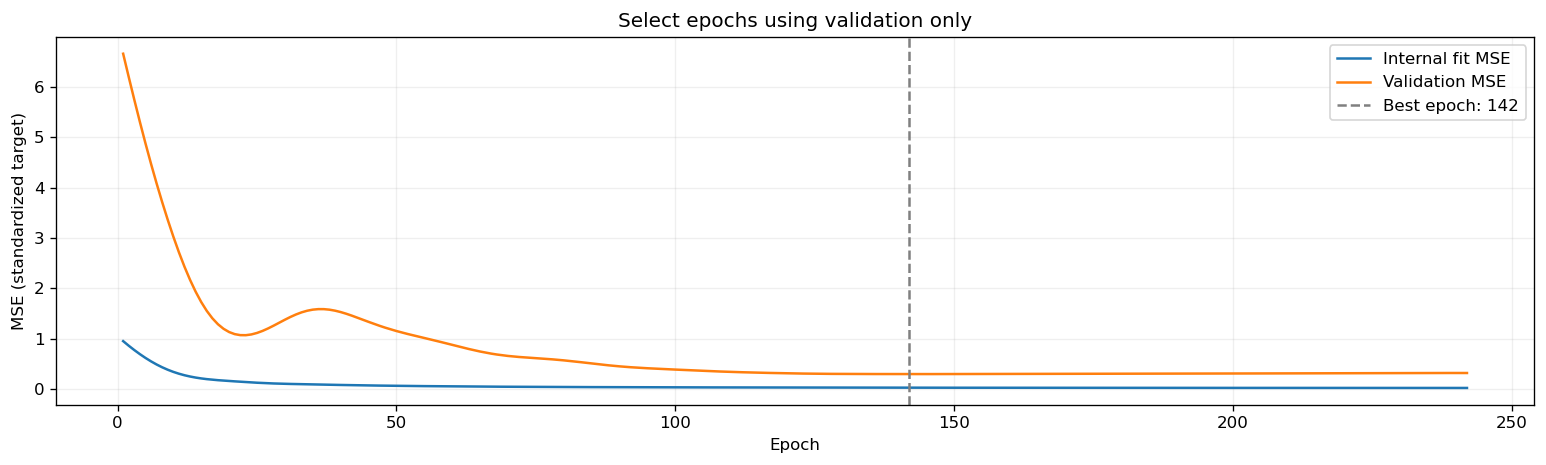

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
best_val_loss, best_epoch, waiting = float('inf'), 0, 0
best_state = None
history_rows = []
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    loss = loss_fn(model(X_fit_tensor), Y_fit_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        fit_mse = loss_fn(model(X_fit_tensor), Y_fit_tensor).item()
        val_mse = loss_fn(model(X_val_tensor), Y_val_tensor).item()
    assert np.isfinite(fit_mse) and np.isfinite(val_mse)
    history_rows.append([epoch, fit_mse, val_mse])
    if val_mse < best_val_loss - MIN_DELTA:
        best_val_loss, best_epoch, waiting = val_mse, epoch, 0
        best_state = deepcopy(model.state_dict())
    else:
        waiting += 1
    if waiting >= PATIENCE:
        break
last_epoch = epoch
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    assert np.isclose(loss_fn(model(X_val_tensor), Y_val_tensor).item(), best_val_loss)
history = pd.DataFrame(history_rows, columns=['epoch', 'fit_mse', 'val_mse'])
history.to_csv(OUT / 'selection_history.csv', index=False)
print(f'最佳轮数：{best_epoch}；实际停止轮数：{last_epoch}；'
      f'停止原因：{"连续 100 轮未明显改善" if waiting >= PATIENCE else "达到轮数上限"}')
print(f'最佳验证标准化 MSE：{best_val_loss:.6f}')
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(history.epoch, history.fit_mse, label='Internal fit MSE')
ax.plot(history.epoch, history.val_mse, label='Validation MSE')
ax.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch: {best_epoch}')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Select epochs using validation only')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'selection_mse.png', dpi=140)
plt.show()


## 5. 用完整训练集重新训练选定轮数

重新在完整训练集拟合标准化器，重新初始化网络，训练 `best_epoch` 轮。这里保存的是最终模型；它不同于上一块的内部验证最佳模型。轮数已经选定，此阶段不根据测试误差提前停止。

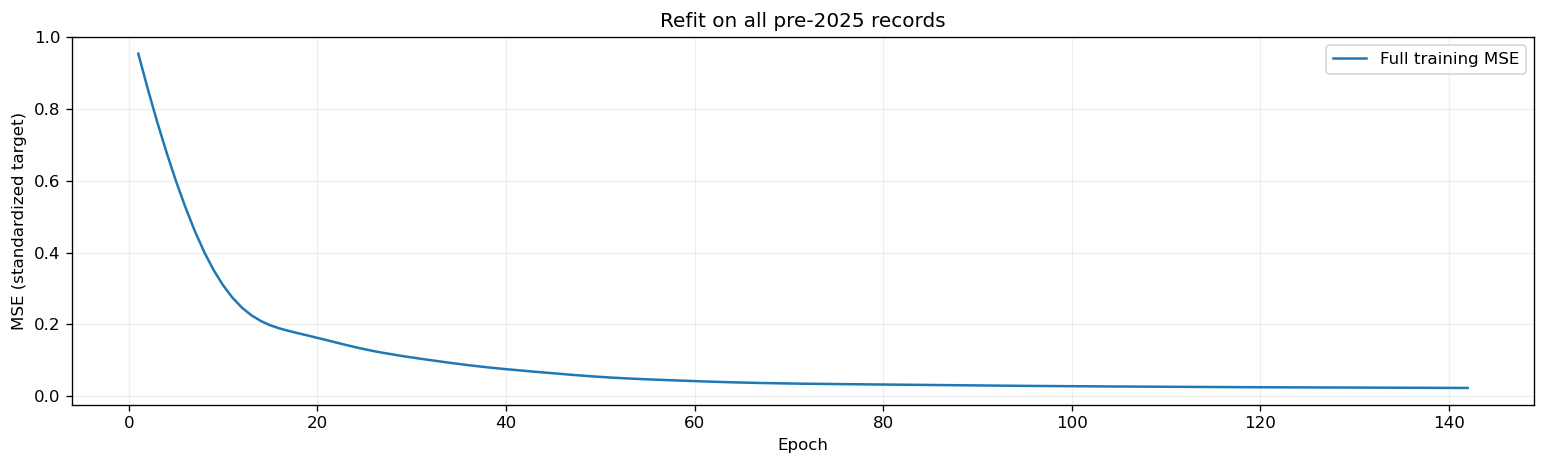

In [ ]:
scaler_x_final = StandardScaler().fit(X_train)
scaler_y_final = StandardScaler().fit(Y_train.to_numpy().reshape(-1, 1))
X_train_tensor = to_tensor(scaler_x_final.transform(X_train))
Y_train_tensor = to_tensor(scaler_y_final.transform(Y_train.to_numpy().reshape(-1, 1)))
mlp = build_mlp()
final_optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
final_losses = []
for epoch in range(1, best_epoch + 1):
    mlp.train()
    loss = loss_fn(mlp(X_train_tensor), Y_train_tensor)
    final_optimizer.zero_grad()
    loss.backward()
    final_optimizer.step()
    mlp.eval()
    with torch.no_grad():
        final_losses.append(loss_fn(mlp(X_train_tensor), Y_train_tensor).item())
assert np.isfinite(final_losses).all()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(1, best_epoch + 1), final_losses, label='Full training MSE')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Refit on all pre-2025 records')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'refit_mse.png', dpi=140)
plt.show()

# 同时保存两阶段权重及各自的标准化参数；恢复时必须配套使用。
def scaler_state(scaler):
    return {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
torch.save({
    'model_state_dict': mlp.state_dict(), 'internal_best_state_dict': best_state,
    'feature_names': list(X.columns), 'hidden': HIDDEN, 'seed': SEED, 'lr': LR,
    'best_epoch': best_epoch, 'stopped_epoch': last_epoch,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'min_delta': MIN_DELTA,
    'test_start': str(TEST_START.date()), 'validation_fraction': VAL_FRACTION,
    'scaler_x_final': scaler_state(scaler_x_final), 'scaler_y_final': scaler_state(scaler_y_final),
    'scaler_x_internal': scaler_state(scaler_x), 'scaler_y_internal': scaler_state(scaler_y),
    'dataset_sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest()
}, OUT / 'mlp_checkpoint.pt')


## 6. 最终模型在训练集和测试集上的误差

预测反标准化到原股价单位，报告 MSE、RMSE、MAE、R²及平均残差（实际−预测）。正的平均残差表示整体偏低估。测试期变短、日期也不同，不能直接把本次分数和旧 500 条测试期的分数当作同条件比较。

In [ ]:
def predict_price(frame):
    mlp.eval()
    with torch.no_grad():
        values = mlp(to_tensor(scaler_x_final.transform(frame))).cpu().numpy()
    return scaler_y_final.inverse_transform(values).ravel()
predictions = {}
metric_rows = []
for label, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    pred = predict_price(features)
    actual = np.asarray(truth).ravel()
    residual = actual - pred
    frame = pd.DataFrame({'Actual': actual, 'Predicted': pred, 'Residual': residual}, index=truth.index)
    assert np.isfinite(frame.to_numpy()).all()
    predictions[label] = frame
    frame.to_csv(OUT / f'{label.lower()}_predictions.csv')
    mse = mean_squared_error(actual, pred)
    metric_rows.append({'数据段': label, 'MSE': mse, 'RMSE': np.sqrt(mse),
                       'MAE': np.abs(residual).mean(), 'R²': r2_score(actual, pred),
                       '平均残差': residual.mean()})
metrics = pd.DataFrame(metric_rows).set_index('数据段')
metrics.to_csv(OUT / 'metrics.csv')
display(metrics.round(4))


,MSE,RMSE,MAE,R²,平均残差
数据段,,,,,
Train,0.4310,0.6565,0.4744,0.9768,-0.0309
Test,15.5362,3.9416,3.5976,0.7464,-0.1861


## 7. 实际值与预测值：训练集、测试集分开画

上图灰色部分是曾用于内部选轮的验证区间，**已参与最终模型的完整训练**。下图紫色部分为最终测试期。使用同一个最终模型预测两段数据，不做事后平移修正。

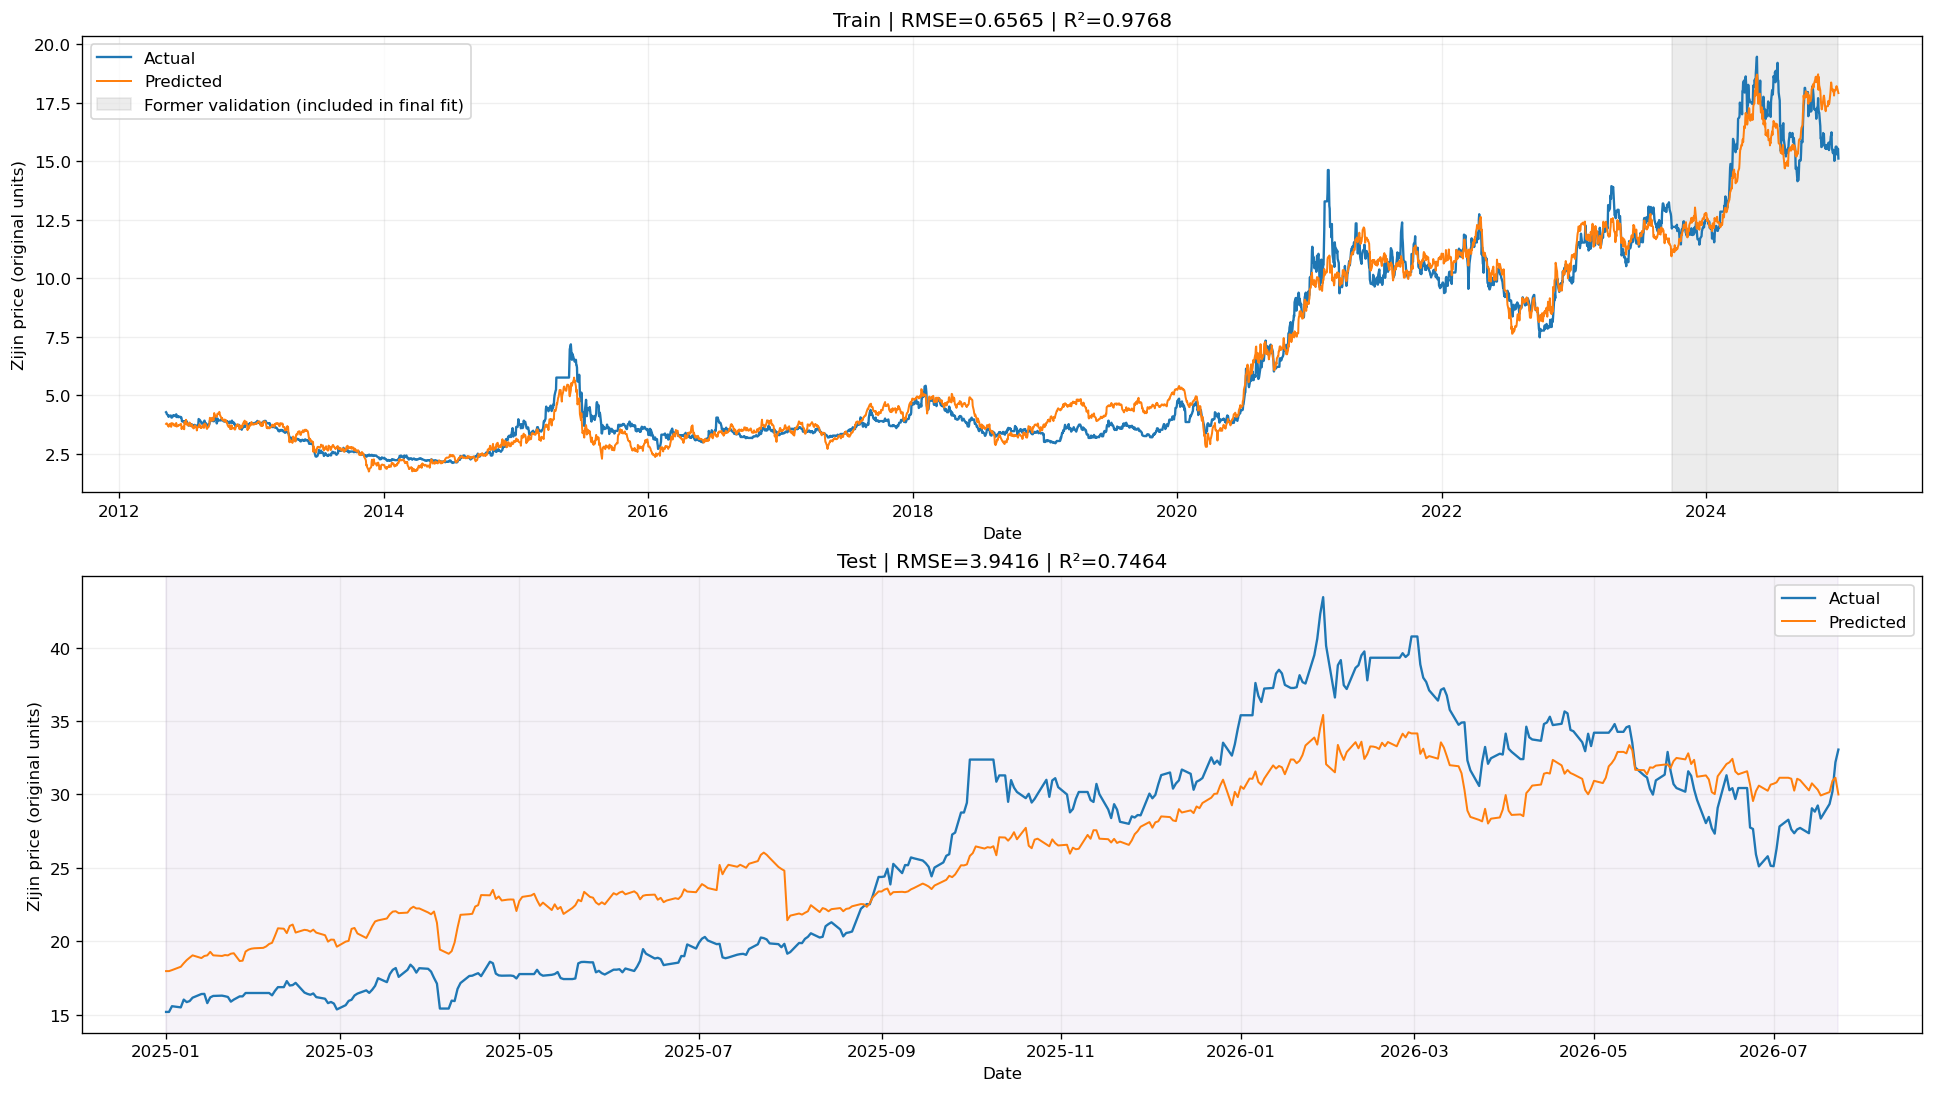

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, label in zip(axes, ['Train', 'Test']):
    frame = predictions[label]
    ax.plot(frame.index, frame.Actual, color='tab:blue', label='Actual', linewidth=1.4)
    ax.plot(frame.index, frame.Predicted, color='tab:orange', label='Predicted', linewidth=1.2)
    if label == 'Train':
        ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.15,
                   label='Former validation (included in final fit)')
    else:
        ax.axvspan(frame.index.min(), frame.index.max(), color='tab:purple', alpha=0.08)
    ax.set(title=f'{label} | RMSE={metrics.loc[label, "RMSE"]:.4f} | R²={metrics.loc[label, "R²"]:.4f}',
           xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'predictions.png', dpi=140)
plt.show()


可以看到,新增了训练集,对于后面的预测有很大的帮助.

## 8. 残差随时间变化

残差为实际值减预测值。观察偏差是否集中在某些年份、是否持续低估，而不仅仅看整体分数。

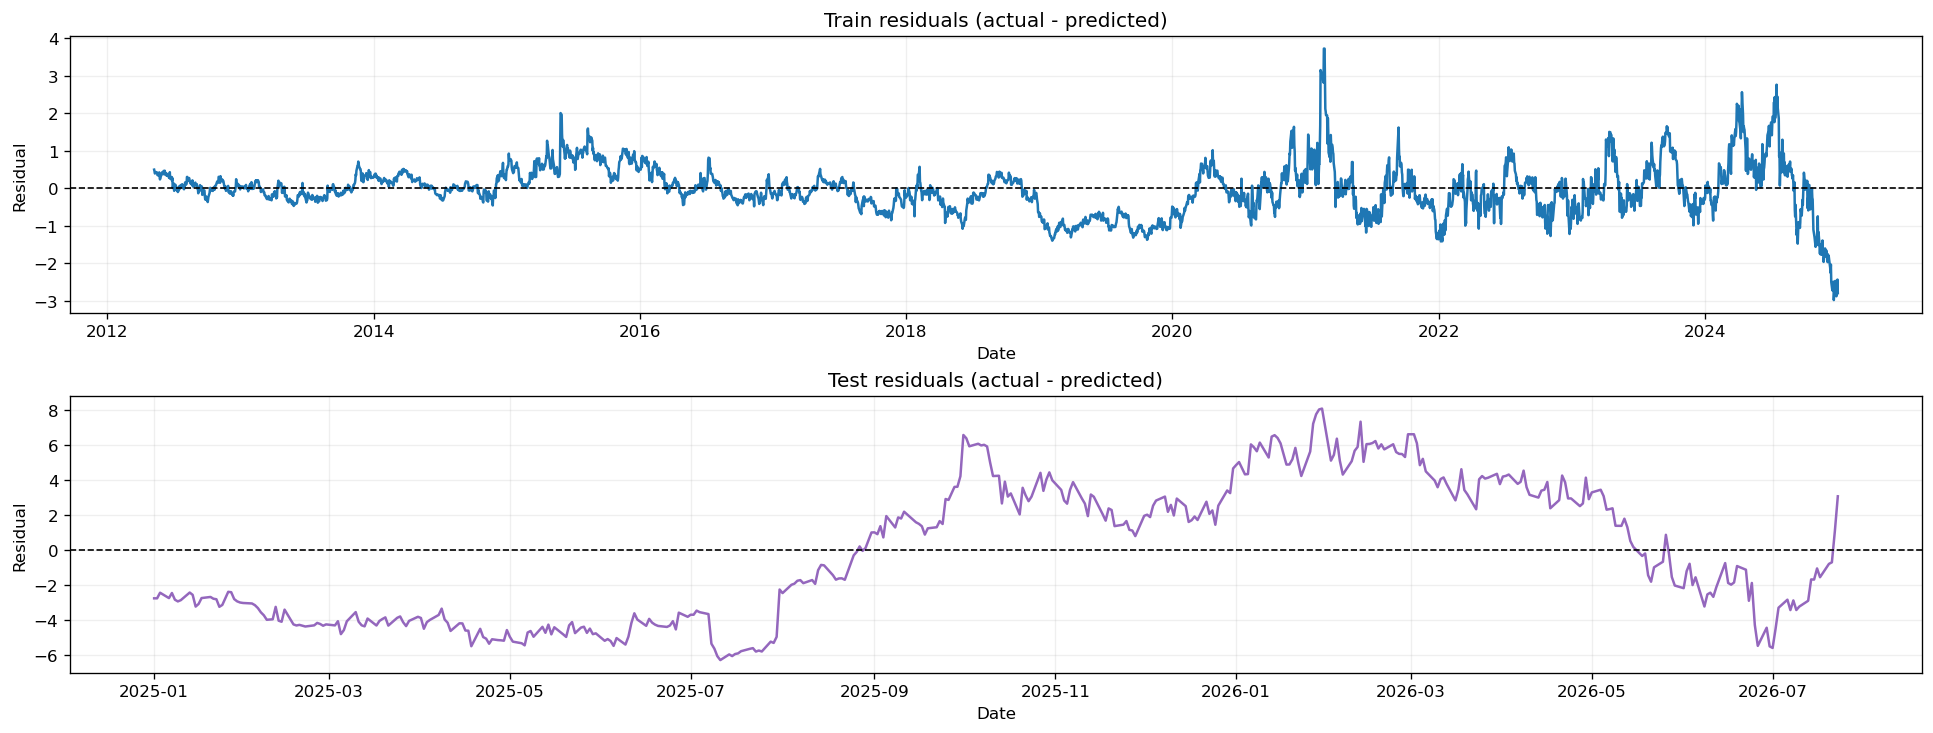

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), constrained_layout=True)
for ax, label in zip(axes, ['Train', 'Test']):
    frame = predictions[label]
    ax.plot(frame.index, frame.Residual, color='tab:blue' if label == 'Train' else 'tab:purple')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set(title=f'{label} residuals (actual - predicted)', xlabel='Date', ylabel='Residual')
    ax.grid(alpha=0.2)
fig.savefig(OUT / 'residuals.png', dpi=140)
plt.show()


## 本次运行记录

内部验证选择 **142 轮**，实际在第 **242 轮**结束。随后在全部 2025 年之前的记录上重新训练 142 轮。

| 数据段   |     MSE |   RMSE |    MAE |     R² |   平均残差 |
|:---------|--------:|-------:|-------:|-------:|-----------:|
| Train    |  0.431  | 0.6565 | 0.4744 | 0.9768 |    -0.0309 |
| Test     | 15.5362 | 3.9416 | 3.5976 | 0.7464 |    -0.1861 |

完整训练集 3417 条，内部拟合集 3075 条，内部验证集 342 条；最终测试集 420 条。

所有图片、预测明细、训练曲线及配套标准化参数的模型权重保存在 `results/mlp_test_from_2025/`。

本次扩大了拟合期，同时改变了验证和测试时间范围，因此分数变化不能单独归因于输入覆盖改善。沿用原数据的同日因子解释同日股价，并未转换为明日预测；旧数据填充方式尚未重新审计。以上记录在改动参数后需要同步更新。

# 同一时间范围：Lasso 与 MLP 对比

直接复用上面的 `X_train / Y_train`（2025 年之前）和 `X_test / Y_test`（2025-01-01 起），七个输入因子、目标及记录顺序完全一致。

Lasso 沿用先前配置：`StandardScaler → Lasso(max_iter=10000)`，在完整训练集内部做五折 `TimeSeriesSplit`，对 10⁻⁵～10¹ 的 1000 个 alpha 搜索，以交叉验证 RMSE 选参数，最后自动在完整训练集重训。每折单独拟合标准化器，测试集不参与调参。

MLP 用最后 10% 内部验证段选轮数，Lasso 用五折时间序列验证选 alpha；这是同一外部划分下两种训练流程的对比，内部调参规则并不完全相同。Lasso 不采用神经网络的 2000 轮／100 轮早停规则。

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import joblib

lasso_2025_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])
lasso_2025_search = GridSearchCV(
    lasso_2025_pipeline,
    param_grid={'lasso__alpha': np.logspace(-5, 1, 1000)},
    cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error',
    refit=True, n_jobs=1, error_score='raise')
lasso_2025_search.fit(X_train, np.asarray(Y_train).ravel())
print('Lasso 最佳 alpha：', lasso_2025_search.best_params_['lasso__alpha'])
print('五折平均验证 RMSE：', -lasso_2025_search.best_score_)
print('最终模型迭代次数：', lasso_2025_search.best_estimator_['lasso'].n_iter_)
joblib.dump(lasso_2025_search.best_estimator_, OUT / 'lasso_pipeline.joblib')


Lasso 最佳 alpha： 1e-05
五折平均验证 RMSE： 1.8527748132018356
最终模型迭代次数： 119


## Lasso 的验证误差曲线

横轴为惩罚参数 alpha，不是训练轮数。蓝线为各折验证 MSE 的算术平均值；竖线标注按平均 RMSE 选出的 alpha。纵轴使用原股价平方单位，不能与前面的标准化目标 MSE 直接比较。

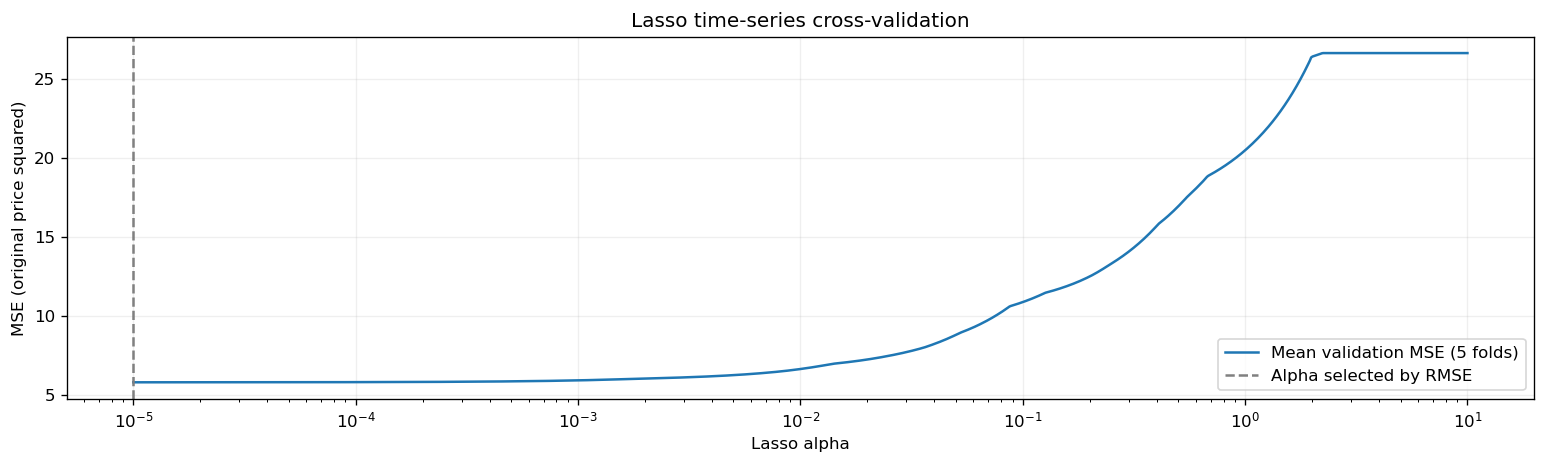

In [ ]:
lasso_cv = pd.DataFrame(lasso_2025_search.cv_results_)
lasso_cv_alpha = lasso_cv['param_lasso__alpha'].astype(float).to_numpy()
lasso_fold_rmse = np.column_stack([
    -lasso_cv[f'split{k}_test_score'].to_numpy() for k in range(5)])
lasso_cv_summary = pd.DataFrame({
    'alpha': lasso_cv_alpha,
    'mean_validation_rmse': lasso_fold_rmse.mean(axis=1),
    'mean_validation_mse': (lasso_fold_rmse ** 2).mean(axis=1)})
lasso_cv_summary.to_csv(OUT / 'lasso_cv.csv', index=False)
fig, ax = plt.subplots(figsize=(13, 4))
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_validation_mse, label='Mean validation MSE (5 folds)')
ax.axvline(lasso_2025_search.best_params_['lasso__alpha'], color='gray', linestyle='--', label='Alpha selected by RMSE')
ax.set(xlabel='Lasso alpha', ylabel='MSE (original price squared)', title='Lasso time-series cross-validation')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'lasso_cv_mse.png', dpi=140)
plt.show()


## 同一批样本上的误差表

两种模型的预测均在原股价单位下评价。MSE、RMSE、MAE 越低越好，R² 越高越好。平均残差定义为实际−预测，正数表示低估。

In [ ]:
comparison_predictions = {}
comparison_rows = []
for split, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    assert predictions[split].index.equals(truth.index)
    assert np.allclose(predictions[split]['Actual'], np.asarray(truth).ravel())
    frame = predictions[split][['Actual', 'Predicted']].rename(columns={'Predicted': 'MLP'}).copy()
    frame['Lasso'] = lasso_2025_search.predict(features)
    assert np.isfinite(frame.to_numpy()).all()
    comparison_predictions[split] = frame
    frame.to_csv(OUT / f'comparison_{split.lower()}_predictions.csv')
    for name in ['MLP', 'Lasso']:
        residual = frame.Actual - frame[name]
        mse = mean_squared_error(frame.Actual, frame[name])
        comparison_rows.append({'数据段': split, '模型': name, 'MSE': mse,
            'RMSE': np.sqrt(mse), 'MAE': np.abs(residual).mean(),
            'R²': r2_score(frame.Actual, frame[name]), '平均残差': residual.mean()})
comparison_metrics = pd.DataFrame(comparison_rows).set_index(['数据段', '模型'])
display(comparison_metrics.round(4))
comparison_metrics.to_csv(OUT / 'comparison_metrics.csv')
print('测试集 RMSE 较小的模型：', comparison_metrics.loc['Test', 'RMSE'].idxmin())
print('MLP 相对 Lasso 的测试 RMSE 降幅：'
      f"{(1 - comparison_metrics.loc[('Test', 'MLP'), 'RMSE'] / comparison_metrics.loc[('Test', 'Lasso'), 'RMSE']) * 100:.2f}%（负值表示 MLP 更差）")


测试集 RMSE 较小的模型： MLP
MLP 相对 Lasso 的测试 RMSE 降幅：3.26%（负值表示 MLP 更差）


MSE    RMSE     MAE      R²    平均残差
数据段   模型                                            
Train MLP     0.4310  0.6565  0.4744  0.9768 -0.0309
      Lasso   0.6808  0.8251  0.6371  0.9634  0.0000
Test  MLP    15.5362  3.9416  3.5976  0.7464 -0.1861
      Lasso  16.6010  4.0744  3.6802  0.7290  0.1376

## 训练集和测试集：实际股价、MLP、Lasso

与之前的上下两幅图格式一致。灰色段是 MLP 曾用于选轮的内部验证区间，现已参与两种最终模型的完整训练；淡紫色是最终测试期。

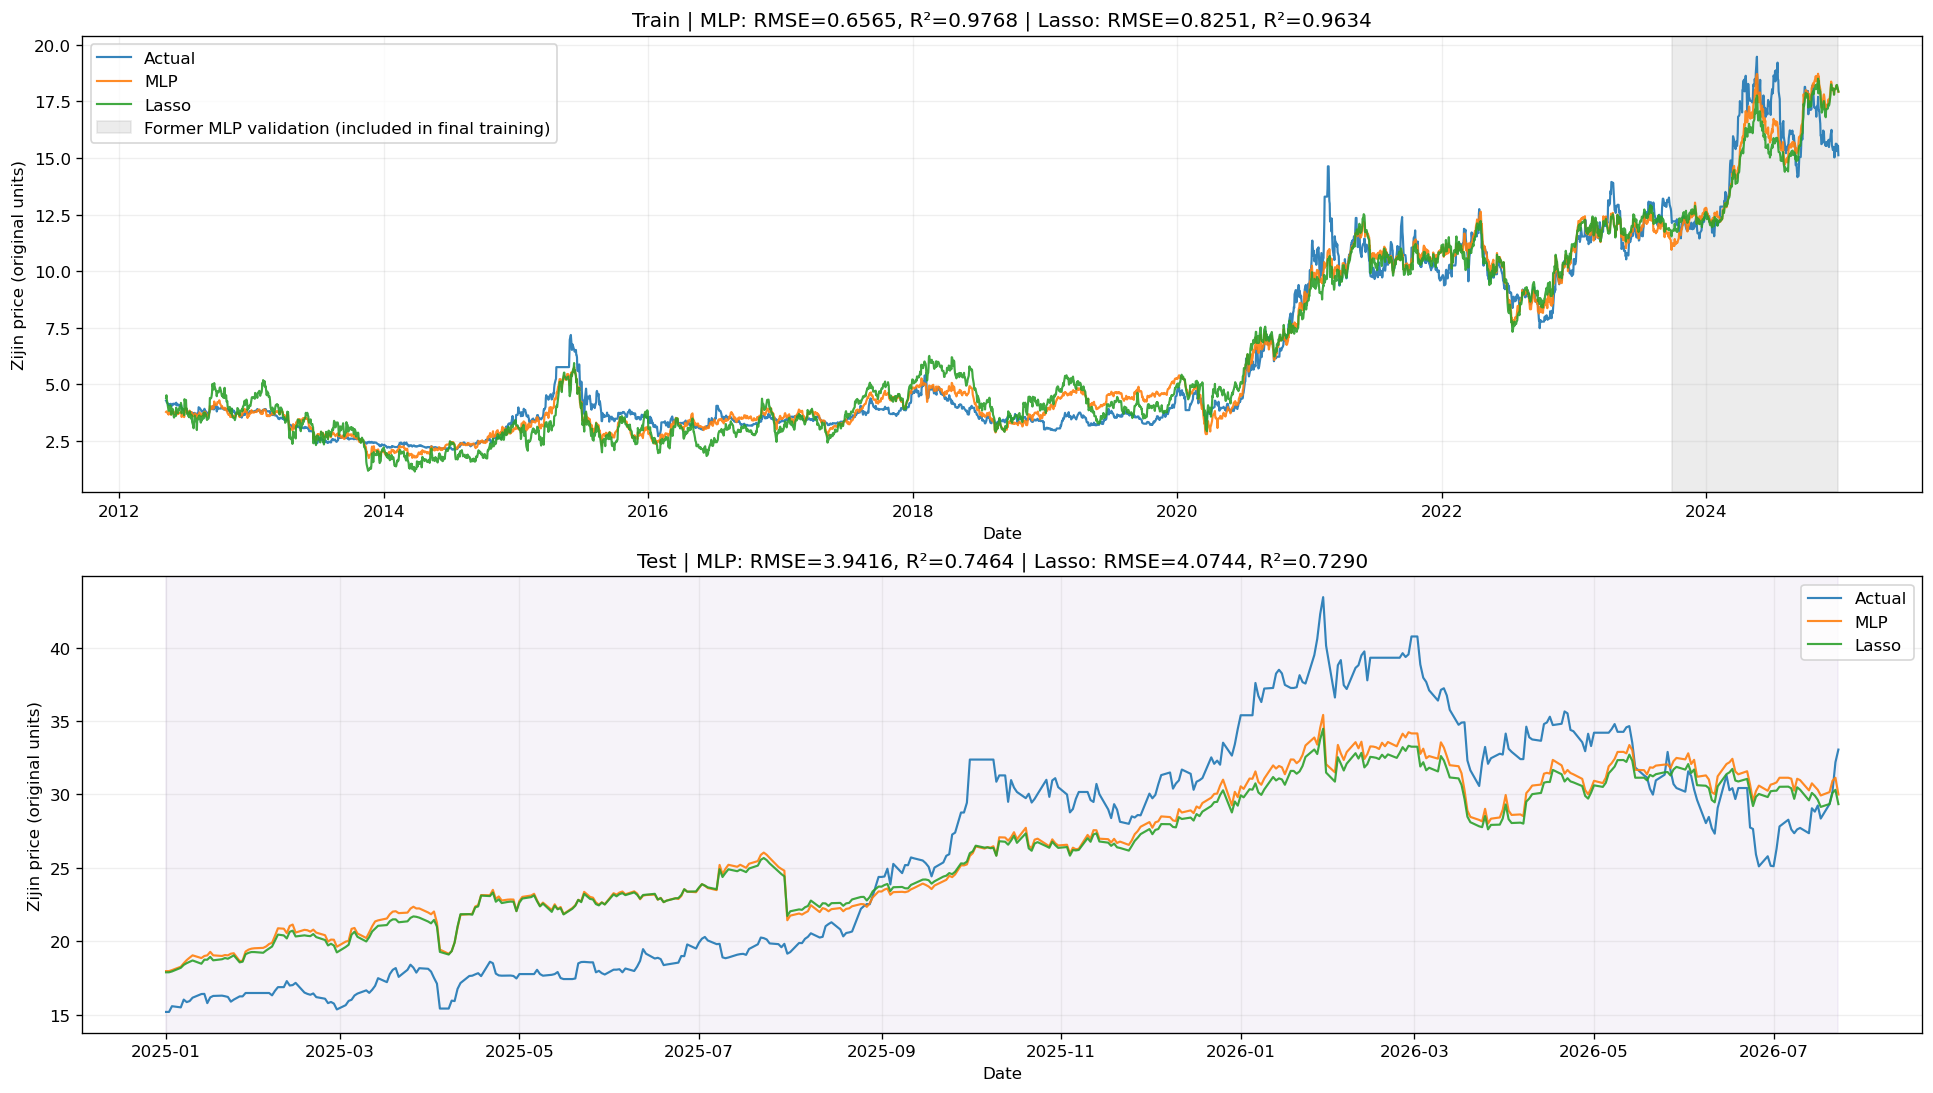

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split in zip(axes, ['Train', 'Test']):
    frame = comparison_predictions[split]
    for name, color in [('Actual', 'tab:blue'), ('MLP', 'tab:orange'), ('Lasso', 'tab:green')]:
        ax.plot(frame.index, frame[name], color=color, label=name, linewidth=1.3, alpha=0.9)
    if split == 'Train':
        ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.15,
                   label='Former MLP validation (included in final training)')
    else:
        ax.axvspan(frame.index.min(), frame.index.max(), color='tab:purple', alpha=0.08)
    row_mlp = comparison_metrics.loc[(split, 'MLP')]
    row_lasso = comparison_metrics.loc[(split, 'Lasso')]
    ax.set(title=f'{split} | MLP: RMSE={row_mlp.RMSE:.4f}, R²={row_mlp["R²"]:.4f}'
           f' | Lasso: RMSE={row_lasso.RMSE:.4f}, R²={row_lasso["R²"]:.4f}',
           xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'mlp_lasso_predictions.png', dpi=140)
plt.show()


## 残差对比

两种模型的残差均以零为基准；观察误差在不同时间段的方向和幅度。

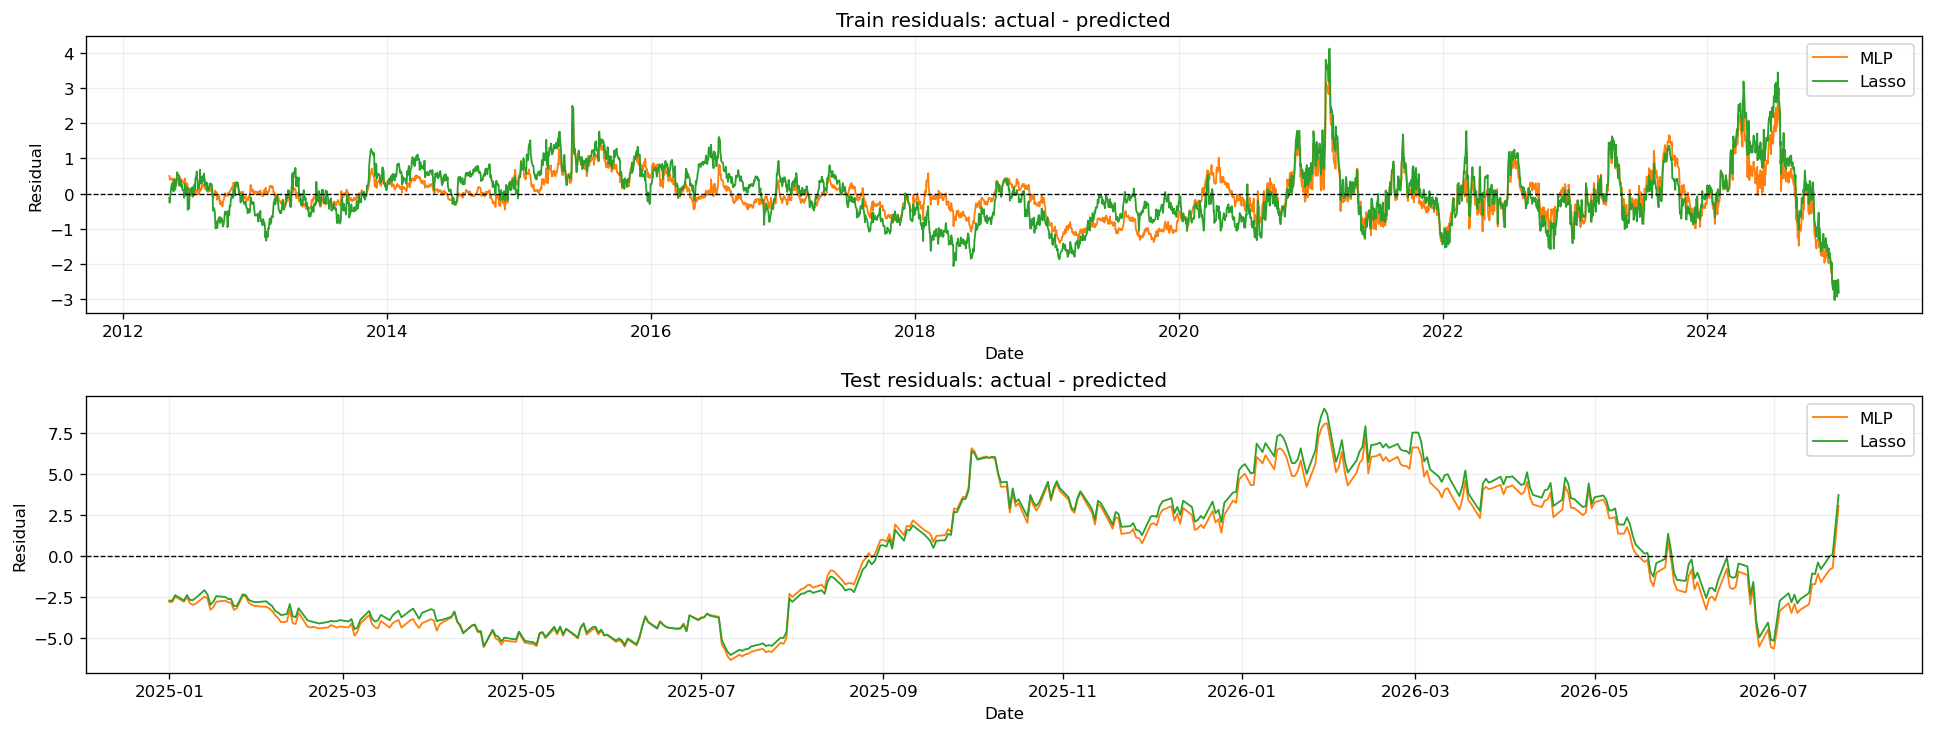

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), constrained_layout=True)
for ax, split in zip(axes, ['Train', 'Test']):
    frame = comparison_predictions[split]
    for name, color in [('MLP', 'tab:orange'), ('Lasso', 'tab:green')]:
        ax.plot(frame.index, frame.Actual - frame[name], label=name, color=color, linewidth=1.1)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set(title=f'{split} residuals: actual - predicted', xlabel='Date', ylabel='Residual')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'mlp_lasso_residuals.png', dpi=140)
plt.show()


## 本次 Lasso 对比运行记录

Lasso 最佳 alpha 为 **1e-05**。

|                    |     MSE |   RMSE |    MAE |     R² |   平均残差 |
|:-------------------|--------:|-------:|-------:|-------:|-----------:|
| ('Train', 'MLP')   |  0.431  | 0.6565 | 0.4744 | 0.9768 |    -0.0309 |
| ('Train', 'Lasso') |  0.6808 | 0.8251 | 0.6371 | 0.9634 |     0      |
| ('Test', 'MLP')    | 15.5362 | 3.9416 | 3.5976 | 0.7464 |    -0.1861 |
| ('Test', 'Lasso')  | 16.601  | 4.0744 | 3.6802 | 0.729  |     0.1376 |

以上结果使用相同的训练和测试日期、相同七个因子和同一目标。比较仅适用于本次设置，不能仅凭一次划分判断模型普遍优劣；原始数据和同日解释口径的限制沿用前文。重新修改参数或数据后，需要同步更新本段记录。

---

就结果而言,一个简单模型的效果与Lasso接近.但是中间的突变仍然无法解释.是否是因为数据集仍然不够?

# 2026 年测试集：训练期扩展至 2025 年底，验证比例 5%

本节可以从这里按顺序独立运行。使用 2026-01-01 及以后记录作为测试集，之前全部作为完整训练集；末尾 5%（按记录数，验证数向上取整）留作内部验证。

MLP 保持 7→8→1、ReLU、Adam、学习率 0.01、seed=42、最多 2000 轮。验证标准化 MSE 比已记录最优值下降超过 1e-6 才计作改善，连续 100 轮未改善则停止；恢复最佳权重，再在完整训练集重新初始化并训练选定轮数。

Lasso 沿用五折时间序列交叉验证及 1000 个 alpha 网格，在同一完整训练集上训练，测试数据不用于选参数。本次保留 MSE 曲线、误差表、预测对比图，不新增残差图或残差明细。

这次只改变数据时间划分与 MLP 验证比例。两个模型的外部训练／测试样本一致，内部选参数方法不同。

In [ ]:
from pathlib import Path
from copy import deepcopy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'src/pickle/Dataset.pkl').exists())
OUT = PROJECT_ROOT / 'results/mlp_test_from_2026'
OUT.mkdir(parents=True, exist_ok=True)
SEED, HIDDEN, LR = 42, 8, 0.01
MAX_EPOCHS, PATIENCE, MIN_DELTA = 2000, 100, 1e-6
TEST_START, VAL_FRACTION = pd.Timestamp('2026-01-01'), 0.05
torch.set_num_threads(1)
device = torch.device('cpu')
print('PyTorch:', torch.__version__)


PyTorch: 2.14.0


## 1. 新的日期划分和范围覆盖

扩大训练范围之后，仍需检查黄金、铜和利率是否超出完整训练期范围。范围内不等于所有组合都已见过，范围外也不等于预测必然失败。

In [ ]:
dataset_path = PROJECT_ROOT / 'src/pickle/Dataset.pkl'
Dataset = pd.read_pickle(dataset_path)
X = Dataset['X'].copy()
Y = Dataset['Y'].copy()
expected = ['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate',
            'brent', 'Copper Futures Price', 'Gold Futures Price']
assert list(X.columns) == expected and X.index.equals(Y.index)
assert isinstance(X.index, pd.DatetimeIndex)
assert X.index.is_monotonic_increasing and X.index.is_unique
assert np.isfinite(X.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
X_train, X_test = X.loc[X.index < TEST_START].copy(), X.loc[X.index >= TEST_START].copy()
Y_train, Y_test = Y.loc[X_train.index].copy(), Y.loc[X_test.index].copy()
cut = int(len(X_train) * (1 - VAL_FRACTION))
X_fit, X_val = X_train.iloc[:cut], X_train.iloc[cut:]
Y_fit, Y_val = Y_train.iloc[:cut], Y_train.iloc[cut:]
assert min(len(X_fit), len(X_val), len(X_test)) > 1
assert X_fit.index.max() < X_val.index.min() <= X_val.index.max() < X_test.index.min()
split_info = pd.DataFrame([
    {'数据段': name, '记录数': len(frame), '开始': frame.index.min(), '结束': frame.index.max()}
    for name, frame in [('完整训练集', X_train), ('内部拟合集', X_fit),
                        ('内部验证集', X_val), ('测试集', X_test)]])
display(split_info)


,数据段,记录数,开始,结束
0,完整训练集,3685,2012-05-09,2025-12-31
1,内部拟合集,3500,2012-05-09,2025-04-23
2,内部验证集,185,2025-04-24,2025-12-31
3,测试集,152,2026-01-01,2026-07-23


In [ ]:
coverage = pd.DataFrame(index=X.columns)
for label, reference, future in [
    ('验证超出内部拟合范围 (%)', X_fit, X_val),
    ('测试超出内部拟合范围 (%)', X_fit, X_test),
    ('测试超出完整训练范围 (%)', X_train, X_test)]:
    coverage[label] = ((future < reference.min()) | (future > reference.max())).mean() * 100
display(coverage.round(2))


,验证超出内部拟合范围 (%),测试超出内部拟合范围 (%),测试超出完整训练范围 (%)
A_500,0.00,0.00,0.00
Dollar Index,0.00,0.00,0.00
cn_10y_rate,0.00,0.00,0.00
us_10y_rate,0.00,0.00,0.00
brent,0.00,1.97,1.97
Copper Futures Price,22.70,100.00,73.03
Gold Futures Price,54.05,100.00,61.84


## 2. MLP：标准化、训练及验证早停

标准化器仅在内部拟合集拟合。下图记录每轮更新后的内部拟合／验证 MSE，纵轴为标准化目标的平方单位。

In [ ]:
scaler_x = StandardScaler().fit(X_fit)
scaler_y = StandardScaler().fit(Y_fit.to_numpy().reshape(-1, 1))
def to_tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32, device=device)
X_fit_tensor = to_tensor(scaler_x.transform(X_fit))
X_val_tensor = to_tensor(scaler_x.transform(X_val))
Y_fit_tensor = to_tensor(scaler_y.transform(Y_fit.to_numpy().reshape(-1, 1)))
Y_val_tensor = to_tensor(scaler_y.transform(Y_val.to_numpy().reshape(-1, 1)))
def build_mlp():
    torch.manual_seed(SEED)
    return nn.Sequential(nn.Linear(7, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, 1)).to(device)
model = build_mlp()
loss_fn = nn.MSELoss()
print(model)
print('参数数量：', sum(p.numel() for p in model.parameters()))


Sequential(
  (0): Linear(in_features=7, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
参数数量： 73


最佳轮数：69；实际停止轮数：169；停止原因：连续 100 轮未明显改善
最佳验证标准化 MSE：0.923523


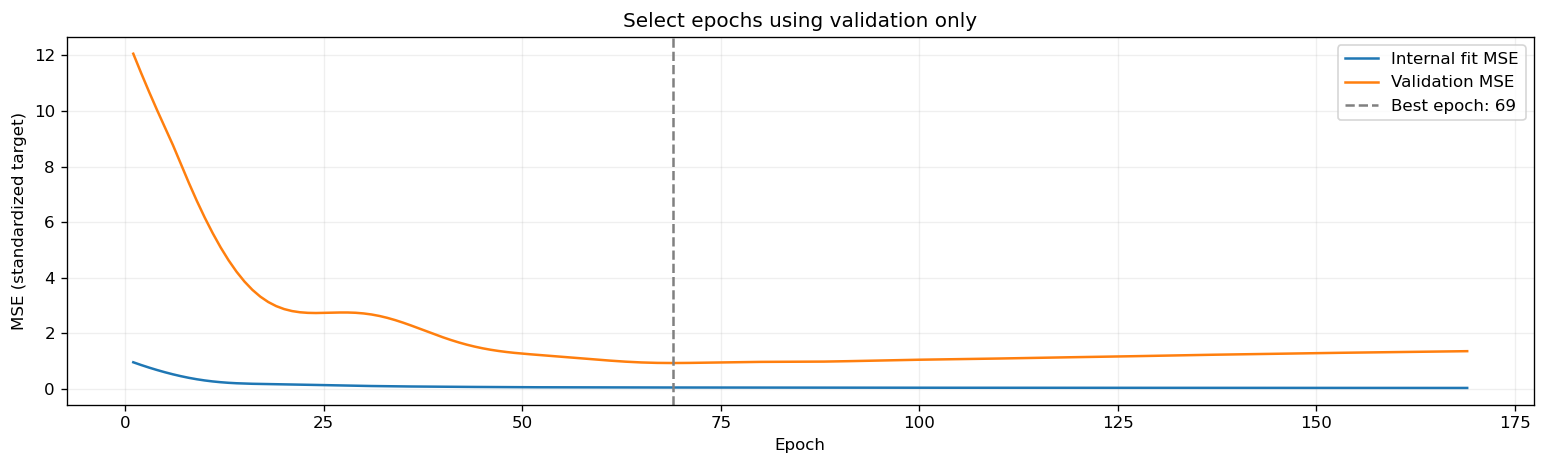

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
best_val_loss, best_epoch, waiting = float('inf'), 0, 0
best_state = None
history_rows = []
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    loss = loss_fn(model(X_fit_tensor), Y_fit_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        fit_mse = loss_fn(model(X_fit_tensor), Y_fit_tensor).item()
        val_mse = loss_fn(model(X_val_tensor), Y_val_tensor).item()
    assert np.isfinite(fit_mse) and np.isfinite(val_mse)
    history_rows.append([epoch, fit_mse, val_mse])
    if val_mse < best_val_loss - MIN_DELTA:
        best_val_loss, best_epoch, waiting = val_mse, epoch, 0
        best_state = deepcopy(model.state_dict())
    else:
        waiting += 1
    if waiting >= PATIENCE:
        break
last_epoch = epoch
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    assert np.isclose(loss_fn(model(X_val_tensor), Y_val_tensor).item(), best_val_loss)
history = pd.DataFrame(history_rows, columns=['epoch', 'fit_mse', 'val_mse'])
history.to_csv(OUT / 'selection_history.csv', index=False)
print(f'最佳轮数：{best_epoch}；实际停止轮数：{last_epoch}；'
      f'停止原因：{"连续 100 轮未明显改善" if waiting >= PATIENCE else "达到轮数上限"}')
print(f'最佳验证标准化 MSE：{best_val_loss:.6f}')
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(history.epoch, history.fit_mse, label='Internal fit MSE')
ax.plot(history.epoch, history.val_mse, label='Validation MSE')
ax.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch: {best_epoch}')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Select epochs using validation only')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'selection_mse.png', dpi=140)
plt.show()


## 3. MLP：完整训练期重训

使用验证选定轮数，在全部 2026 年之前的训练样本上重新训练。标准化器也只在这段完整训练数据上重新拟合。保存内部最佳权重和最终模型，以及配套的标准化参数。

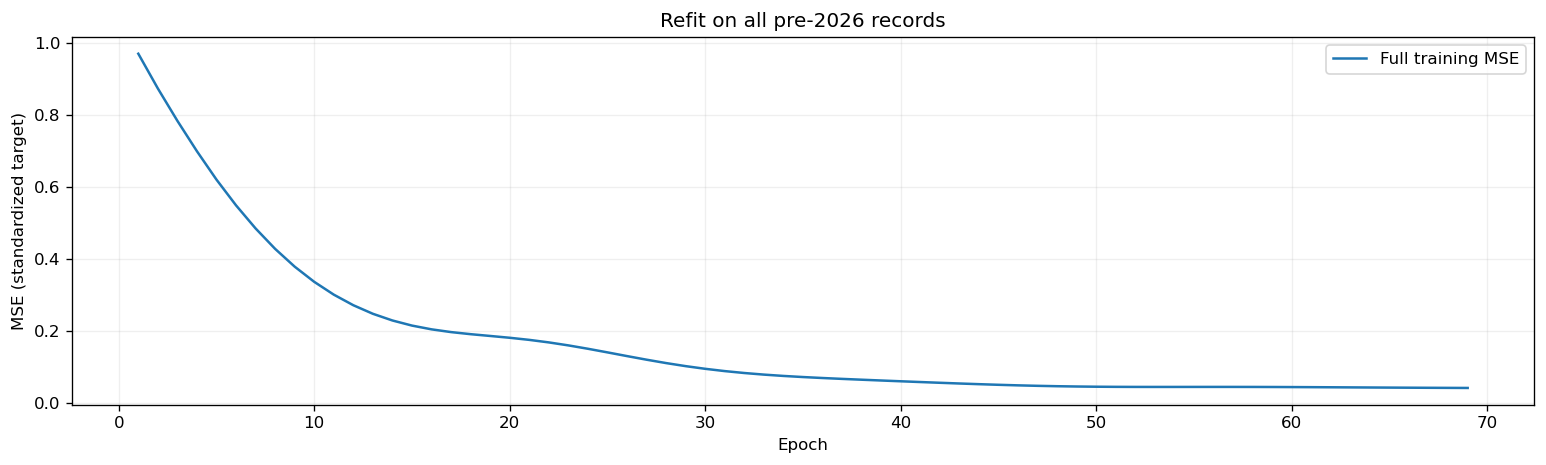

In [ ]:
scaler_x_final = StandardScaler().fit(X_train)
scaler_y_final = StandardScaler().fit(Y_train.to_numpy().reshape(-1, 1))
X_train_tensor = to_tensor(scaler_x_final.transform(X_train))
Y_train_tensor = to_tensor(scaler_y_final.transform(Y_train.to_numpy().reshape(-1, 1)))
mlp = build_mlp()
final_optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
final_losses = []
for epoch in range(1, best_epoch + 1):
    mlp.train()
    loss = loss_fn(mlp(X_train_tensor), Y_train_tensor)
    final_optimizer.zero_grad()
    loss.backward()
    final_optimizer.step()
    mlp.eval()
    with torch.no_grad():
        final_losses.append(loss_fn(mlp(X_train_tensor), Y_train_tensor).item())
assert np.isfinite(final_losses).all()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(1, best_epoch + 1), final_losses, label='Full training MSE')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Refit on all pre-2026 records')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'refit_mse.png', dpi=140)
plt.show()

# 同时保存两阶段权重及各自的标准化参数；恢复时必须配套使用。
def scaler_state(scaler):
    return {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
torch.save({
    'model_state_dict': mlp.state_dict(), 'internal_best_state_dict': best_state,
    'feature_names': list(X.columns), 'hidden': HIDDEN, 'seed': SEED, 'lr': LR,
    'best_epoch': best_epoch, 'stopped_epoch': last_epoch,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'min_delta': MIN_DELTA,
    'test_start': str(TEST_START.date()), 'validation_fraction': VAL_FRACTION,
    'scaler_x_final': scaler_state(scaler_x_final), 'scaler_y_final': scaler_state(scaler_y_final),
    'scaler_x_internal': scaler_state(scaler_x), 'scaler_y_internal': scaler_state(scaler_y),
    'dataset_sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest()
}, OUT / 'mlp_checkpoint.pt')


## 4. 最终 MLP 预测

保持前面预测图的数据格式，计算原股价单位下的误差，不保存残差列。

In [ ]:
def predict_price(frame):
    mlp.eval()
    with torch.no_grad():
        values = mlp(to_tensor(scaler_x_final.transform(frame))).cpu().numpy()
    return scaler_y_final.inverse_transform(values).ravel()
predictions = {}
metric_rows = []
for label, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    pred = predict_price(features)
    actual = np.asarray(truth).ravel()
    residual = actual - pred
    frame = pd.DataFrame({'Actual': actual, 'Predicted': pred}, index=truth.index)
    assert np.isfinite(frame.to_numpy()).all()
    predictions[label] = frame
    frame.to_csv(OUT / f'{label.lower()}_predictions.csv')
    mse = mean_squared_error(actual, pred)
    metric_rows.append({'数据段': label, 'MSE': mse, 'RMSE': np.sqrt(mse),
                       'MAE': np.abs(residual).mean(), 'R²': r2_score(actual, pred)})
metrics = pd.DataFrame(metric_rows).set_index('数据段')
metrics.to_csv(OUT / 'metrics.csv')
display(metrics.round(4))


,MSE,RMSE,MAE,R²
数据段,,,,
Train,1.5276,1.2359,0.8519,0.9572
Test,18.3186,4.2800,3.8538,-0.0694


## 5. Lasso：相同训练集，时间序列交叉验证

每折单独拟合 StandardScaler，alpha 范围仍为 10⁻⁵～10¹，共 1000 个候选，按平均验证 RMSE 选择。最终在完整训练集自动重新拟合。

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import joblib

lasso_2026_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])
lasso_2026_search = GridSearchCV(
    lasso_2026_pipeline,
    param_grid={'lasso__alpha': np.logspace(-5, 1, 1000)},
    cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error',
    refit=True, return_train_score=True, n_jobs=1, error_score='raise')
lasso_2026_search.fit(X_train, np.asarray(Y_train).ravel())
print('Lasso 最佳 alpha：', lasso_2026_search.best_params_['lasso__alpha'])
print('五折平均验证 RMSE：', -lasso_2026_search.best_score_)
print('最终模型迭代次数：', lasso_2026_search.best_estimator_['lasso'].n_iter_)
joblib.dump(lasso_2026_search.best_estimator_, OUT / 'lasso_pipeline.joblib')


Lasso 最佳 alpha： 0.01291549665014884
五折平均验证 RMSE： 1.8220434839482913
最终模型迭代次数： 68


## 6. Lasso 的拟合／验证 MSE

横轴是 alpha，不是训练轮数。两条曲线是五折各自拟合段、验证段 MSE 的算术平均值，使用原股价平方单位；竖线按平均验证 RMSE 选择，不一定对应平均 MSE 的最低点。Lasso 使用坐标下降求解，不具有与 MLP 相同的 epoch 学习曲线。

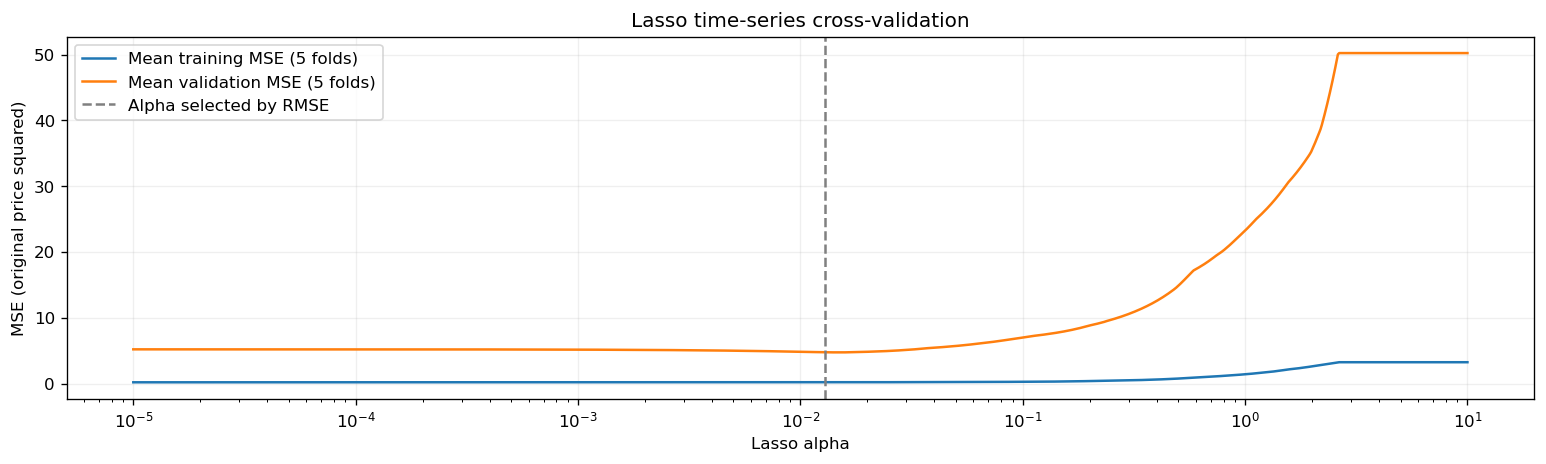

In [ ]:
lasso_cv = pd.DataFrame(lasso_2026_search.cv_results_)
lasso_cv_alpha = lasso_cv['param_lasso__alpha'].astype(float).to_numpy()
lasso_fold_rmse = np.column_stack([
    -lasso_cv[f'split{k}_test_score'].to_numpy() for k in range(5)])
lasso_fold_train_rmse = np.column_stack([
    -lasso_cv[f'split{k}_train_score'].to_numpy() for k in range(5)])
lasso_cv_summary = pd.DataFrame({
    'alpha': lasso_cv_alpha,
    'mean_training_mse': (lasso_fold_train_rmse ** 2).mean(axis=1),
    'mean_validation_rmse': lasso_fold_rmse.mean(axis=1),
    'mean_validation_mse': (lasso_fold_rmse ** 2).mean(axis=1)})
lasso_cv_summary.to_csv(OUT / 'lasso_cv.csv', index=False)
fig, ax = plt.subplots(figsize=(13, 4))
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_training_mse, label='Mean training MSE (5 folds)')
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_validation_mse, label='Mean validation MSE (5 folds)')
ax.axvline(lasso_2026_search.best_params_['lasso__alpha'], color='gray', linestyle='--', label='Alpha selected by RMSE')
ax.set(xlabel='Lasso alpha', ylabel='MSE (original price squared)', title='Lasso time-series cross-validation')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'lasso_cv_mse.png', dpi=140)
plt.show()


## 7. MLP 与 Lasso：同一时间范围的指标表

最终模型都使用完整训练集，测试集均从 2026-01-01 开始。MSE、RMSE、MAE 越小越好，R² 越大越好。

In [ ]:
comparison_predictions = {}
comparison_rows = []
for split, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    assert predictions[split].index.equals(truth.index)
    assert np.allclose(predictions[split]['Actual'], np.asarray(truth).ravel())
    frame = predictions[split][['Actual', 'Predicted']].rename(columns={'Predicted': 'MLP'}).copy()
    frame['Lasso'] = lasso_2026_search.predict(features)
    assert np.isfinite(frame.to_numpy()).all()
    comparison_predictions[split] = frame
    frame.to_csv(OUT / f'comparison_{split.lower()}_predictions.csv')
    for name in ['MLP', 'Lasso']:
        residual = frame.Actual - frame[name]
        mse = mean_squared_error(frame.Actual, frame[name])
        comparison_rows.append({'数据段': split, '模型': name, 'MSE': mse,
            'RMSE': np.sqrt(mse), 'MAE': np.abs(residual).mean(),
            'R²': r2_score(frame.Actual, frame[name])})
comparison_metrics = pd.DataFrame(comparison_rows).set_index(['数据段', '模型'])
display(comparison_metrics.round(4))
comparison_metrics.to_csv(OUT / 'comparison_metrics.csv')
print('测试集 RMSE 较小的模型：', comparison_metrics.loc['Test', 'RMSE'].idxmin())
print('MLP 相对 Lasso 的测试 RMSE 降幅：'
      f"{(1 - comparison_metrics.loc[('Test', 'MLP'), 'RMSE'] / comparison_metrics.loc[('Test', 'Lasso'), 'RMSE']) * 100:.2f}%（负值表示 MLP 更差）")


测试集 RMSE 较小的模型： Lasso
MLP 相对 Lasso 的测试 RMSE 降幅：-13.51%（负值表示 MLP 更差）


MSE    RMSE     MAE      R²
数据段   模型                                    
Train MLP     1.5276  1.2359  0.8519  0.9572
      Lasso   1.4414  1.2006  0.8707  0.9597
Test  MLP    18.3186  4.2800  3.8538 -0.0694
      Lasso  14.2182  3.7707  3.2257  0.1699

## 8. 训练集／测试集预测对比

蓝线为实际股价，橙线为 MLP，绿线为 Lasso。灰色区间曾用于 MLP 选轮，在最终重训时已参与两个模型的训练；淡紫色区域为最终测试期。

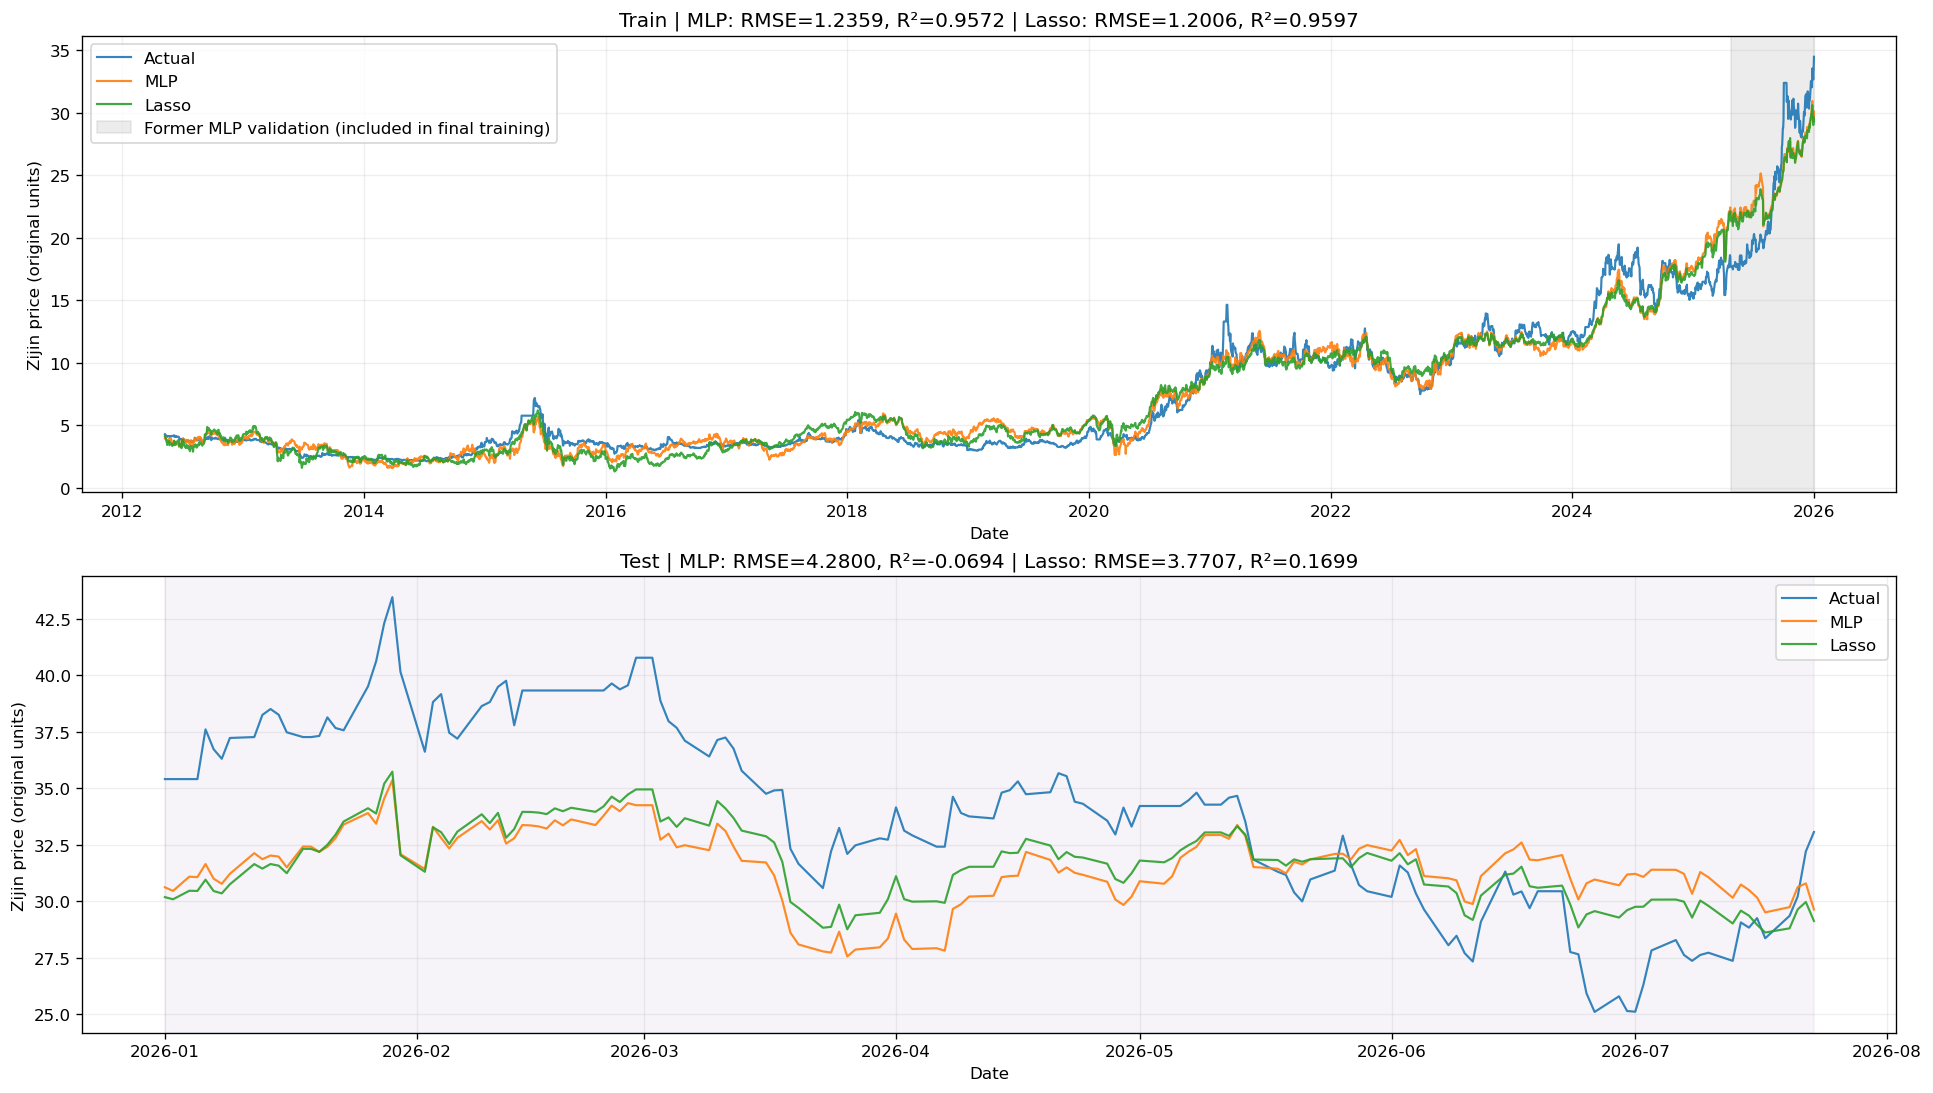

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split in zip(axes, ['Train', 'Test']):
    frame = comparison_predictions[split]
    for name, color in [('Actual', 'tab:blue'), ('MLP', 'tab:orange'), ('Lasso', 'tab:green')]:
        ax.plot(frame.index, frame[name], color=color, label=name, linewidth=1.3, alpha=0.9)
    if split == 'Train':
        ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.15,
                   label='Former MLP validation (included in final training)')
    else:
        ax.axvspan(frame.index.min(), frame.index.max(), color='tab:purple', alpha=0.08)
    row_mlp = comparison_metrics.loc[(split, 'MLP')]
    row_lasso = comparison_metrics.loc[(split, 'Lasso')]
    ax.set(title=f'{split} | MLP: RMSE={row_mlp.RMSE:.4f}, R²={row_mlp["R²"]:.4f}'
           f' | Lasso: RMSE={row_lasso.RMSE:.4f}, R²={row_lasso["R²"]:.4f}',
           xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'mlp_lasso_predictions.png', dpi=140)
plt.show()


## 本次运行结果

内部拟合集 3500 条，验证集 185 条；完整训练集 3685 条，测试集 152 条。

MLP 最佳轮数 **69**，实际停止轮数 **169**；最终在完整训练集重新训练 69 轮。Lasso 最佳 alpha **0.012915497**。

|                    |     MSE |   RMSE |    MAE |      R² |
|:-------------------|--------:|-------:|-------:|--------:|
| ('Train', 'MLP')   |  1.5276 | 1.2359 | 0.8519 |  0.9572 |
| ('Train', 'Lasso') |  1.4414 | 1.2006 | 0.8707 |  0.9597 |
| ('Test', 'MLP')    | 18.3186 | 4.28   | 3.8538 | -0.0694 |
| ('Test', 'Lasso')  | 14.2182 | 3.7707 | 3.2257 |  0.1699 |

模型、预测明细、MSE 曲线及对比图保存在 `results/mlp_test_from_2026/`。本次测试时间范围较前一实验更短，不能将分数变化单独归因于扩大训练期。仍沿用原始数据与同日解释口径，不代表明日预测；改动参数后需更新这段运行记录。

# 指定 2026 年一季度验证，4 月起测试

本节可以按顺序独立运行。内部拟合集截至 **2025-12-31**；内部验证集指定为 **2026-01-01 至 2026-03-31**；最终测试集为 **2026-04-01 及以后**，不再按 5% 切分。

保持 MLP 7→8→1、ReLU、Adam、学习率 0.01、seed=42、最多 2000 轮、MIN_DELTA=1e-6，以及连续 100 轮验证误差未改善早停。第一阶段验证样本只选轮数，不更新权重；第二阶段重新初始化，在拟合＋验证的完整训练集（截至 2026-03-31）上训练选定轮数，因此一季度数据会参与最终模型学习。

Lasso 仍在同一完整训练集内进行五折时间序列交叉验证，1000 个 alpha、同一搜索范围与求解设置不变。指定一季度验证指 MLP 的选轮窗口，Lasso 保留原有选参流程。

保留 MSE 曲线、覆盖比例、指标和训练／测试预测对比，不新增残差图。此前最终模型已经训练至 2025 年底；本次不仅延长了内部拟合期，也把最终训练期延长到 2026 年一季度。

In [ ]:
from pathlib import Path
from copy import deepcopy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'src/pickle/Dataset.pkl').exists())
OUT = PROJECT_ROOT / 'results/mlp_validation_2026q1'
OUT.mkdir(parents=True, exist_ok=True)
SEED, HIDDEN, LR = 42, 8, 0.01
MAX_EPOCHS, PATIENCE, MIN_DELTA = 2000, 100, 1e-6
VAL_START = pd.Timestamp('2026-01-01')
TEST_START = pd.Timestamp('2026-04-01')
torch.set_num_threads(1)
device = torch.device('cpu')
print('PyTorch:', torch.__version__)


PyTorch: 2.14.0


## 1. 新的日期划分和范围覆盖

扩大训练范围之后，仍需检查黄金、铜和利率是否超出完整训练期范围。范围内不等于所有组合都已见过，范围外也不等于预测必然失败。

In [ ]:
dataset_path = PROJECT_ROOT / 'src/pickle/Dataset.pkl'
Dataset = pd.read_pickle(dataset_path)
X = Dataset['X'].copy()
Y = Dataset['Y'].copy()
expected = ['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate',
            'brent', 'Copper Futures Price', 'Gold Futures Price']
assert list(X.columns) == expected and X.index.equals(Y.index)
assert isinstance(X.index, pd.DatetimeIndex)
assert X.index.is_monotonic_increasing and X.index.is_unique
assert np.isfinite(X.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
X_train, X_test = X.loc[X.index < TEST_START].copy(), X.loc[X.index >= TEST_START].copy()
Y_train, Y_test = Y.loc[X_train.index].copy(), Y.loc[X_test.index].copy()
X_fit = X_train.loc[X_train.index < VAL_START].copy()
X_val = X_train.loc[X_train.index >= VAL_START].copy()
Y_fit, Y_val = Y_train.loc[X_fit.index], Y_train.loc[X_val.index]
assert X_fit.index.max() < VAL_START <= X_val.index.min()
assert X_val.index.max() < TEST_START
assert X_fit.index.append(X_val.index).equals(X_train.index)
assert min(len(X_fit), len(X_val), len(X_test)) > 1
assert X_fit.index.max() < X_val.index.min() <= X_val.index.max() < X_test.index.min()
split_info = pd.DataFrame([
    {'数据段': name, '记录数': len(frame), '开始': frame.index.min(), '结束': frame.index.max()}
    for name, frame in [('完整训练集', X_train), ('内部拟合集', X_fit),
                        ('内部验证集', X_val), ('测试集', X_test)]])
display(split_info)


,数据段,记录数,开始,结束
0,完整训练集,3754,2012-05-09,2026-03-31
1,内部拟合集,3685,2012-05-09,2025-12-31
2,内部验证集,69,2026-01-01,2026-03-31
3,测试集,83,2026-04-01,2026-07-23


In [ ]:
coverage = pd.DataFrame(index=X.columns)
for label, reference, future in [
    ('验证超出内部拟合范围 (%)', X_fit, X_val),
    ('测试超出内部拟合范围 (%)', X_fit, X_test),
    ('测试超出完整训练范围 (%)', X_train, X_test)]:
    coverage[label] = ((future < reference.min()) | (future > reference.max())).mean() * 100
display(coverage.round(2))


,验证超出内部拟合范围 (%),测试超出内部拟合范围 (%),测试超出完整训练范围 (%)
A_500,0.00,0.00,0.00
Dollar Index,0.00,0.00,0.00
cn_10y_rate,0.00,0.00,0.00
us_10y_rate,0.00,0.00,0.00
brent,0.00,3.61,3.61
Copper Futures Price,50.72,91.57,59.04
Gold Futures Price,81.16,45.78,0.00


## 2. MLP：标准化、训练及验证早停

标准化器仅在内部拟合集拟合。下图记录每轮更新后的内部拟合／验证 MSE，纵轴为标准化目标的平方单位。

In [ ]:
scaler_x = StandardScaler().fit(X_fit)
scaler_y = StandardScaler().fit(Y_fit.to_numpy().reshape(-1, 1))
def to_tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32, device=device)
X_fit_tensor = to_tensor(scaler_x.transform(X_fit))
X_val_tensor = to_tensor(scaler_x.transform(X_val))
Y_fit_tensor = to_tensor(scaler_y.transform(Y_fit.to_numpy().reshape(-1, 1)))
Y_val_tensor = to_tensor(scaler_y.transform(Y_val.to_numpy().reshape(-1, 1)))
def build_mlp():
    torch.manual_seed(SEED)
    return nn.Sequential(nn.Linear(7, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, 1)).to(device)
model = build_mlp()
loss_fn = nn.MSELoss()
print(model)
print('参数数量：', sum(p.numel() for p in model.parameters()))


Sequential(
  (0): Linear(in_features=7, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
参数数量： 73


最佳轮数：291；实际停止轮数：391；停止原因：连续 100 轮未明显改善
最佳验证标准化 MSE：0.202780


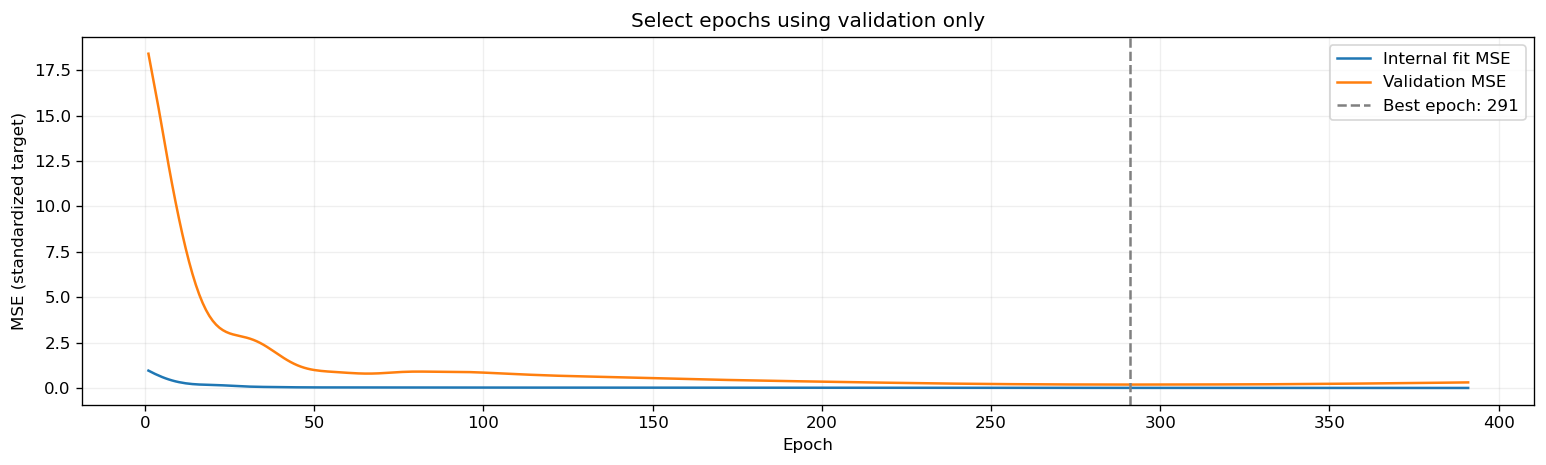

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
best_val_loss, best_epoch, waiting = float('inf'), 0, 0
best_state = None
history_rows = []
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    loss = loss_fn(model(X_fit_tensor), Y_fit_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        fit_mse = loss_fn(model(X_fit_tensor), Y_fit_tensor).item()
        val_mse = loss_fn(model(X_val_tensor), Y_val_tensor).item()
    assert np.isfinite(fit_mse) and np.isfinite(val_mse)
    history_rows.append([epoch, fit_mse, val_mse])
    if val_mse < best_val_loss - MIN_DELTA:
        best_val_loss, best_epoch, waiting = val_mse, epoch, 0
        best_state = deepcopy(model.state_dict())
    else:
        waiting += 1
    if waiting >= PATIENCE:
        break
last_epoch = epoch
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    assert np.isclose(loss_fn(model(X_val_tensor), Y_val_tensor).item(), best_val_loss)
history = pd.DataFrame(history_rows, columns=['epoch', 'fit_mse', 'val_mse'])
history.to_csv(OUT / 'selection_history.csv', index=False)
print(f'最佳轮数：{best_epoch}；实际停止轮数：{last_epoch}；'
      f'停止原因：{"连续 100 轮未明显改善" if waiting >= PATIENCE else "达到轮数上限"}')
print(f'最佳验证标准化 MSE：{best_val_loss:.6f}')
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(history.epoch, history.fit_mse, label='Internal fit MSE')
ax.plot(history.epoch, history.val_mse, label='Validation MSE')
ax.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch: {best_epoch}')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Select epochs using validation only')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'selection_mse.png', dpi=140)
plt.show()


## 3. MLP：完整训练期重训

使用验证选定轮数，在截至 2026-03-31 的全部训练样本上重新训练。标准化器也只在这段完整训练数据上重新拟合。保存内部最佳权重和最终模型，以及配套的标准化参数。

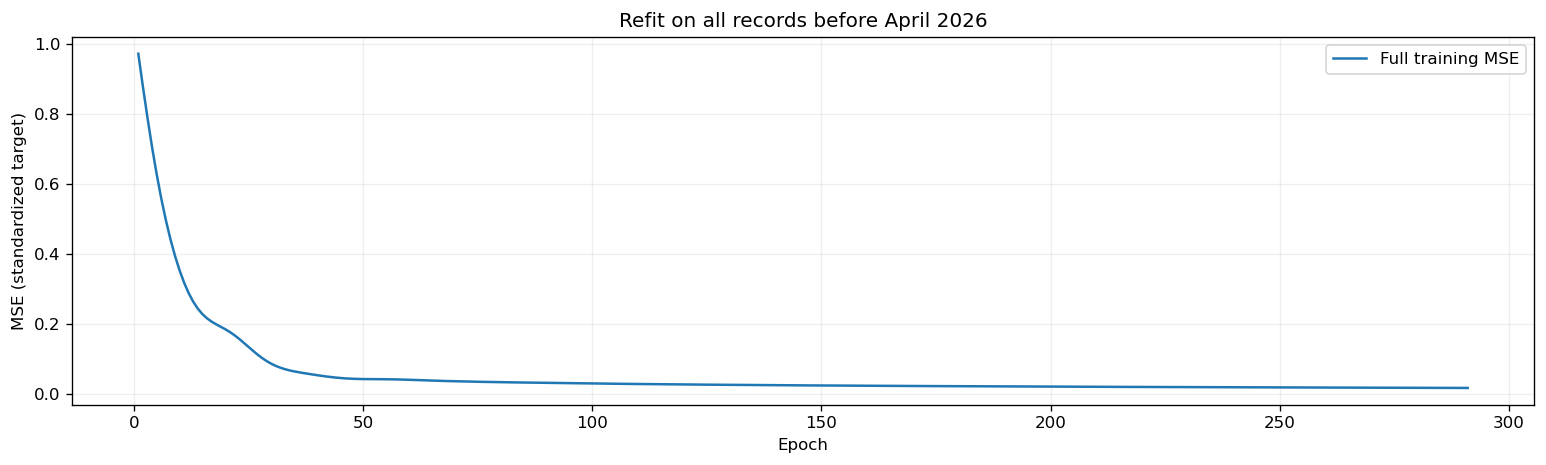

In [ ]:
scaler_x_final = StandardScaler().fit(X_train)
scaler_y_final = StandardScaler().fit(Y_train.to_numpy().reshape(-1, 1))
X_train_tensor = to_tensor(scaler_x_final.transform(X_train))
Y_train_tensor = to_tensor(scaler_y_final.transform(Y_train.to_numpy().reshape(-1, 1)))
mlp = build_mlp()
final_optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
final_losses = []
for epoch in range(1, best_epoch + 1):
    mlp.train()
    loss = loss_fn(mlp(X_train_tensor), Y_train_tensor)
    final_optimizer.zero_grad()
    loss.backward()
    final_optimizer.step()
    mlp.eval()
    with torch.no_grad():
        final_losses.append(loss_fn(mlp(X_train_tensor), Y_train_tensor).item())
assert np.isfinite(final_losses).all()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(1, best_epoch + 1), final_losses, label='Full training MSE')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Refit on all records before April 2026')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'refit_mse.png', dpi=140)
plt.show()

# 同时保存两阶段权重及各自的标准化参数；恢复时必须配套使用。
def scaler_state(scaler):
    return {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
torch.save({
    'model_state_dict': mlp.state_dict(), 'internal_best_state_dict': best_state,
    'feature_names': list(X.columns), 'hidden': HIDDEN, 'seed': SEED, 'lr': LR,
    'best_epoch': best_epoch, 'stopped_epoch': last_epoch,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'min_delta': MIN_DELTA,
    'test_start': str(TEST_START.date()), 'validation_start': str(VAL_START.date()), 'validation_end_exclusive': str(TEST_START.date()),
    'scaler_x_final': scaler_state(scaler_x_final), 'scaler_y_final': scaler_state(scaler_y_final),
    'scaler_x_internal': scaler_state(scaler_x), 'scaler_y_internal': scaler_state(scaler_y),
    'dataset_sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest()
}, OUT / 'mlp_checkpoint.pt')


## 4. 最终 MLP 预测

保持前面预测图的数据格式，计算原股价单位下的误差，不保存残差列。

In [ ]:
def predict_price(frame):
    mlp.eval()
    with torch.no_grad():
        values = mlp(to_tensor(scaler_x_final.transform(frame))).cpu().numpy()
    return scaler_y_final.inverse_transform(values).ravel()
predictions = {}
metric_rows = []
for label, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    pred = predict_price(features)
    actual = np.asarray(truth).ravel()
    residual = actual - pred
    frame = pd.DataFrame({'Actual': actual, 'Predicted': pred}, index=truth.index)
    assert np.isfinite(frame.to_numpy()).all()
    predictions[label] = frame
    frame.to_csv(OUT / f'{label.lower()}_predictions.csv')
    mse = mean_squared_error(actual, pred)
    metric_rows.append({'数据段': label, 'MSE': mse, 'RMSE': np.sqrt(mse),
                       'MAE': np.abs(residual).mean(), 'R²': r2_score(actual, pred)})
metrics = pd.DataFrame(metric_rows).set_index('数据段')
metrics.to_csv(OUT / 'metrics.csv')
display(metrics.round(4))


,MSE,RMSE,MAE,R²
数据段,,,,
Train,0.8567,0.9256,0.6337,0.9833
Test,24.1164,4.9108,4.6806,-1.8346


## 5. Lasso：相同训练集，时间序列交叉验证

每折单独拟合 StandardScaler，alpha 范围仍为 10⁻⁵～10¹，共 1000 个候选，按平均验证 RMSE 选择。最终在完整训练集自动重新拟合。

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import joblib

lasso_2026q1_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])
lasso_2026q1_search = GridSearchCV(
    lasso_2026q1_pipeline,
    param_grid={'lasso__alpha': np.logspace(-5, 1, 1000)},
    cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error',
    refit=True, return_train_score=True, n_jobs=1, error_score='raise')
lasso_2026q1_search.fit(X_train, np.asarray(Y_train).ravel())
print('Lasso 最佳 alpha：', lasso_2026q1_search.best_params_['lasso__alpha'])
print('五折平均验证 RMSE：', -lasso_2026q1_search.best_score_)
print('最终模型迭代次数：', lasso_2026q1_search.best_estimator_['lasso'].n_iter_)
joblib.dump(lasso_2026q1_search.best_estimator_, OUT / 'lasso_pipeline.joblib')


Lasso 最佳 alpha： 0.011092898648952227
五折平均验证 RMSE： 2.1767398276435452
最终模型迭代次数： 57


## 6. Lasso 的拟合／验证 MSE

横轴是 alpha，不是训练轮数。两条曲线是五折各自拟合段、验证段 MSE 的算术平均值，使用原股价平方单位；竖线按平均验证 RMSE 选择，不一定对应平均 MSE 的最低点。Lasso 使用坐标下降求解，不具有与 MLP 相同的 epoch 学习曲线。

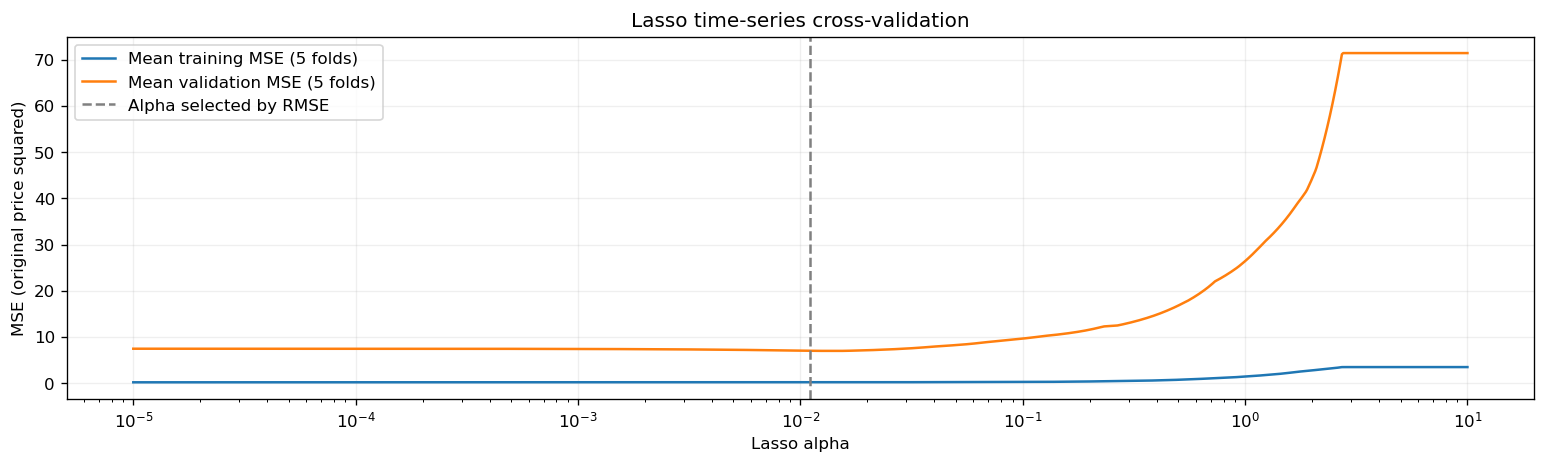

In [ ]:
lasso_cv = pd.DataFrame(lasso_2026q1_search.cv_results_)
lasso_cv_alpha = lasso_cv['param_lasso__alpha'].astype(float).to_numpy()
lasso_fold_rmse = np.column_stack([
    -lasso_cv[f'split{k}_test_score'].to_numpy() for k in range(5)])
lasso_fold_train_rmse = np.column_stack([
    -lasso_cv[f'split{k}_train_score'].to_numpy() for k in range(5)])
lasso_cv_summary = pd.DataFrame({
    'alpha': lasso_cv_alpha,
    'mean_training_mse': (lasso_fold_train_rmse ** 2).mean(axis=1),
    'mean_validation_rmse': lasso_fold_rmse.mean(axis=1),
    'mean_validation_mse': (lasso_fold_rmse ** 2).mean(axis=1)})
lasso_cv_summary.to_csv(OUT / 'lasso_cv.csv', index=False)
fig, ax = plt.subplots(figsize=(13, 4))
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_training_mse, label='Mean training MSE (5 folds)')
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_validation_mse, label='Mean validation MSE (5 folds)')
ax.axvline(lasso_2026q1_search.best_params_['lasso__alpha'], color='gray', linestyle='--', label='Alpha selected by RMSE')
ax.set(xlabel='Lasso alpha', ylabel='MSE (original price squared)', title='Lasso time-series cross-validation')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'lasso_cv_mse.png', dpi=140)
plt.show()


## 7. MLP 与 Lasso：同一时间范围的指标表

最终模型都使用完整训练集，测试集均从 2026-04-01 开始。MSE、RMSE、MAE 越小越好，R² 越大越好。

In [ ]:
comparison_predictions = {}
comparison_rows = []
for split, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    assert predictions[split].index.equals(truth.index)
    assert np.allclose(predictions[split]['Actual'], np.asarray(truth).ravel())
    frame = predictions[split][['Actual', 'Predicted']].rename(columns={'Predicted': 'MLP'}).copy()
    frame['Lasso'] = lasso_2026q1_search.predict(features)
    assert np.isfinite(frame.to_numpy()).all()
    comparison_predictions[split] = frame
    frame.to_csv(OUT / f'comparison_{split.lower()}_predictions.csv')
    for name in ['MLP', 'Lasso']:
        residual = frame.Actual - frame[name]
        mse = mean_squared_error(frame.Actual, frame[name])
        comparison_rows.append({'数据段': split, '模型': name, 'MSE': mse,
            'RMSE': np.sqrt(mse), 'MAE': np.abs(residual).mean(),
            'R²': r2_score(frame.Actual, frame[name])})
comparison_metrics = pd.DataFrame(comparison_rows).set_index(['数据段', '模型'])
display(comparison_metrics.round(4))
comparison_metrics.to_csv(OUT / 'comparison_metrics.csv')
print('测试集 RMSE 较小的模型：', comparison_metrics.loc['Test', 'RMSE'].idxmin())
print('MLP 相对 Lasso 的测试 RMSE 降幅：'
      f"{(1 - comparison_metrics.loc[('Test', 'MLP'), 'RMSE'] / comparison_metrics.loc[('Test', 'Lasso'), 'RMSE']) * 100:.2f}%（负值表示 MLP 更差）")


测试集 RMSE 较小的模型： Lasso
MLP 相对 Lasso 的测试 RMSE 降幅：-108.11%（负值表示 MLP 更差）


MSE    RMSE     MAE      R²
数据段   模型                                    
Train MLP     0.8567  0.9256  0.6337  0.9833
      Lasso   1.6796  1.2960  0.9357  0.9672
Test  MLP    24.1164  4.9108  4.6806 -1.8346
      Lasso   5.5683  2.3597  1.8478  0.3455

## 8. 训练集／测试集预测对比

蓝线为实际股价，橙线为 MLP，绿线为 Lasso。灰色区间曾用于 MLP 选轮，在最终重训时已参与两个模型的训练；淡紫色区域为最终测试期。

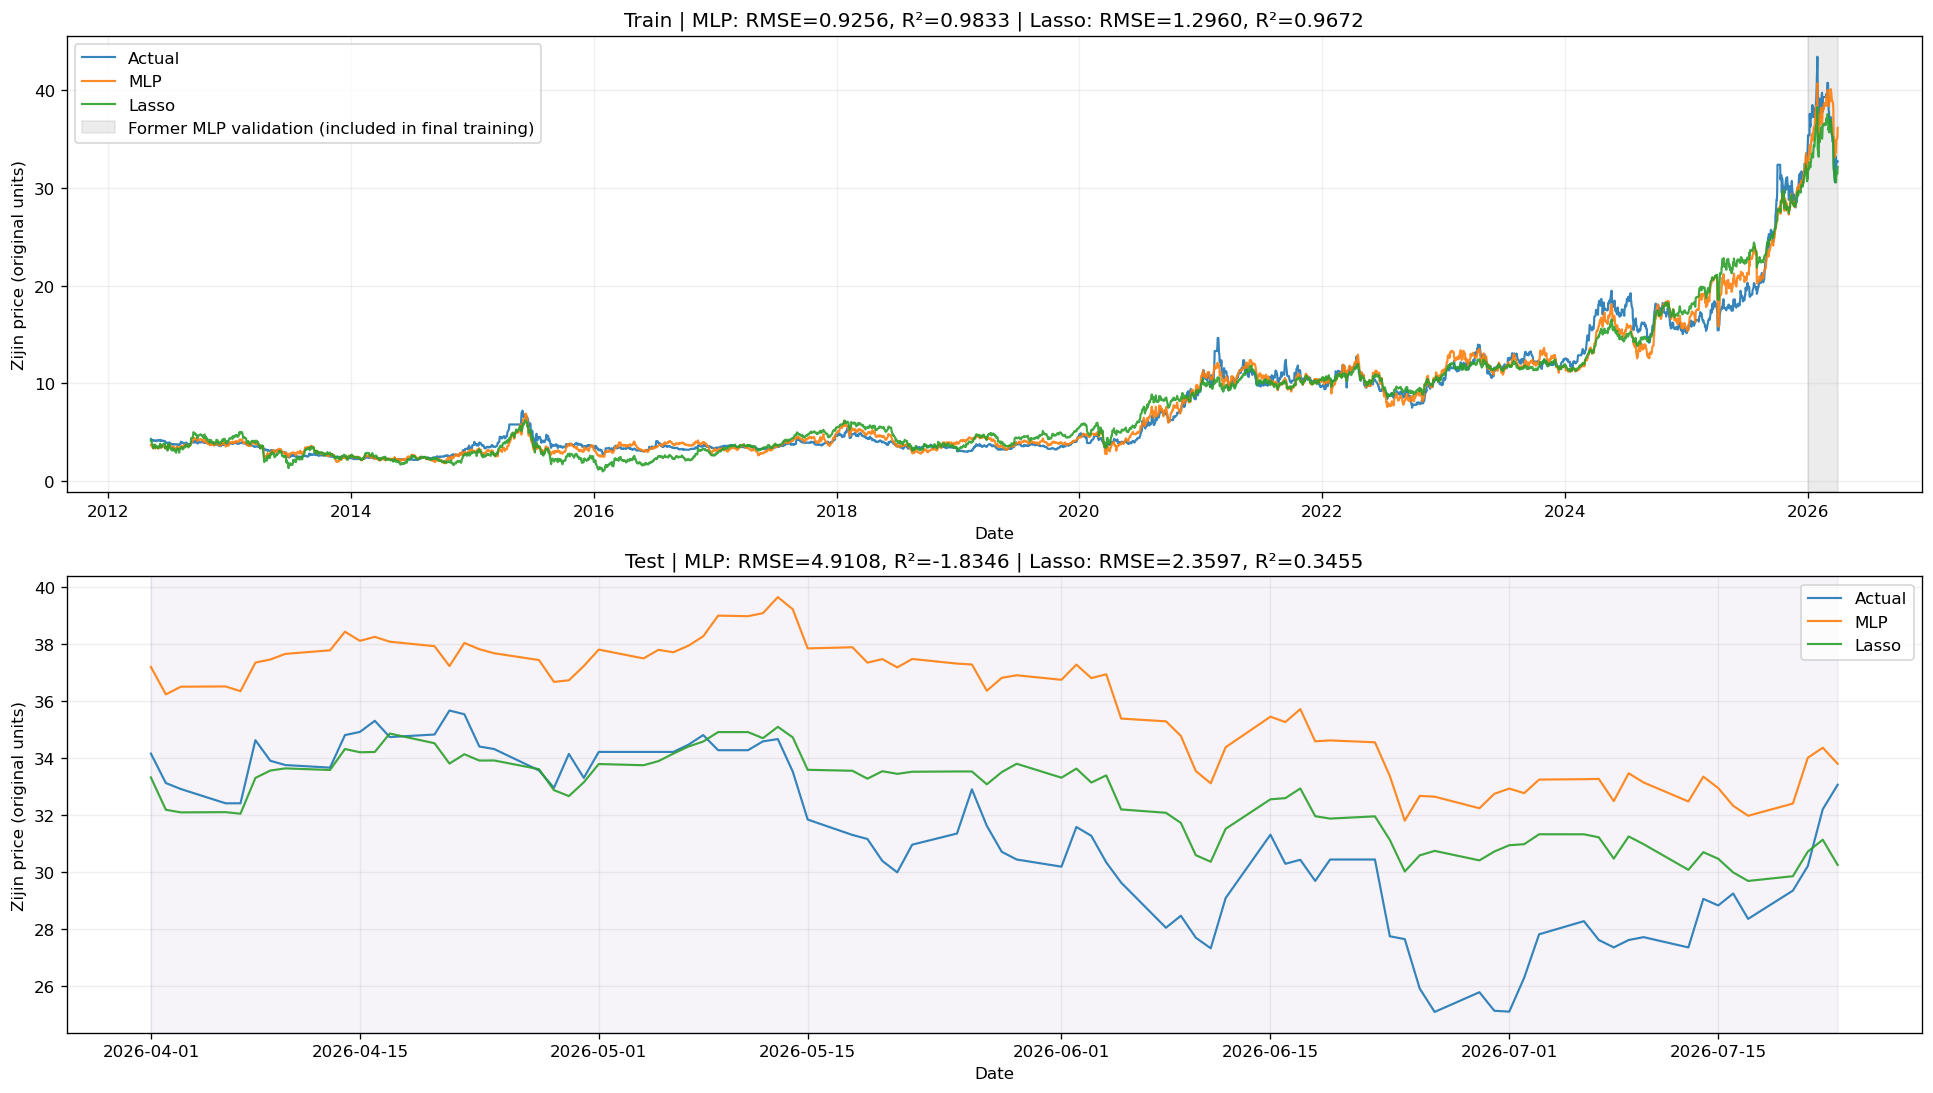

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split in zip(axes, ['Train', 'Test']):
    frame = comparison_predictions[split]
    for name, color in [('Actual', 'tab:blue'), ('MLP', 'tab:orange'), ('Lasso', 'tab:green')]:
        ax.plot(frame.index, frame[name], color=color, label=name, linewidth=1.3, alpha=0.9)
    if split == 'Train':
        ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.15,
                   label='Former MLP validation (included in final training)')
    else:
        ax.axvspan(frame.index.min(), frame.index.max(), color='tab:purple', alpha=0.08)
    row_mlp = comparison_metrics.loc[(split, 'MLP')]
    row_lasso = comparison_metrics.loc[(split, 'Lasso')]
    ax.set(title=f'{split} | MLP: RMSE={row_mlp.RMSE:.4f}, R²={row_mlp["R²"]:.4f}'
           f' | Lasso: RMSE={row_lasso.RMSE:.4f}, R²={row_lasso["R²"]:.4f}',
           xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'mlp_lasso_predictions.png', dpi=140)
plt.show()


## 本次指定日期实验结果

| 数据段     |   记录数 | 开始                | 结束                |
|:-----------|---------:|:--------------------|:--------------------|
| 完整训练集 |     3754 | 2012-05-09 00:00:00 | 2026-03-31 00:00:00 |
| 内部拟合集 |     3685 | 2012-05-09 00:00:00 | 2025-12-31 00:00:00 |
| 内部验证集 |       69 | 2026-01-01 00:00:00 | 2026-03-31 00:00:00 |
| 测试集     |       83 | 2026-04-01 00:00:00 | 2026-07-23 00:00:00 |

MLP 最佳轮数 **291**，实际停止轮数 **391**，完整训练集重训 291 轮。Lasso 最佳 alpha **0.011092899**。

|                    |     MSE |   RMSE |    MAE |      R² |
|:-------------------|--------:|-------:|-------:|--------:|
| ('Train', 'MLP')   |  0.8567 | 0.9256 | 0.6337 |  0.9833 |
| ('Train', 'Lasso') |  1.6796 | 1.296  | 0.9357 |  0.9672 |
| ('Test', 'MLP')    | 24.1164 | 4.9108 | 4.6806 | -1.8346 |
| ('Test', 'Lasso')  |  5.5683 | 2.3597 | 1.8478 |  0.3455 |

结果保存至 `results/mlp_validation_2026q1/`。测试期缩短为四月以后，因此不能将与之前不同测试期的分数差异单独归因于增加近期数据。此前已经查看过这些测试日期的结果，本次属于探索性比较。沿用原始数据、同日解释口径和前文的数据限制；修改设置后需同步更新本段。

## 放大最后模型的训练期：2024 年至 2026 年 3 月

直接读取最后一组已保存的最终模型预测（验证期为 2026 年一季度，测试期从四月开始），仅截取 **2024-01-01 至 2026-03-31**；不重新训练、不调整预测。

下面的 RMSE 和 R² 在这段局部样本上重新计算，R² 的参照均值也取自这一段。它们评价的是最终模型的**训练期拟合表现**，不是测试表现。灰色区域是原内部验证段，已参与最终重训。


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

zoom_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'src/pickle/Dataset.pkl').exists())
zoom_out = zoom_root / 'results/mlp_validation_2026q1'
zoom_full = pd.read_csv(zoom_out / 'comparison_train_predictions.csv', index_col=0, parse_dates=True)
zoom_train = zoom_full.loc['2024-01-01':'2026-03-31', ['Actual', 'MLP', 'Lasso']].copy()
assert len(zoom_train) > 1 and np.isfinite(zoom_train.to_numpy()).all()
assert zoom_train.index.max() < pd.Timestamp('2026-04-01')
zoom_metrics = pd.DataFrame([
    {'模型': name, '样本数': len(zoom_train),
     'RMSE': np.sqrt(mean_squared_error(zoom_train.Actual, zoom_train[name])),
     'R²': r2_score(zoom_train.Actual, zoom_train[name])}
    for name in ['MLP', 'Lasso']]).set_index('模型')
print(f'局部训练期：{zoom_train.index.min().date()} 至 {zoom_train.index.max().date()}')
display(zoom_metrics.round(4))
zoom_metrics.to_csv(zoom_out / 'train_2024_to_2026q1_metrics.csv')
zoom_train.to_csv(zoom_out / 'train_2024_to_2026q1_predictions.csv')


局部训练期：2024-01-01 至 2026-03-31


,样本数,RMSE,R²
模型,,,
MLP,610,1.9047,0.9384
Lasso,610,2.5328,0.8911


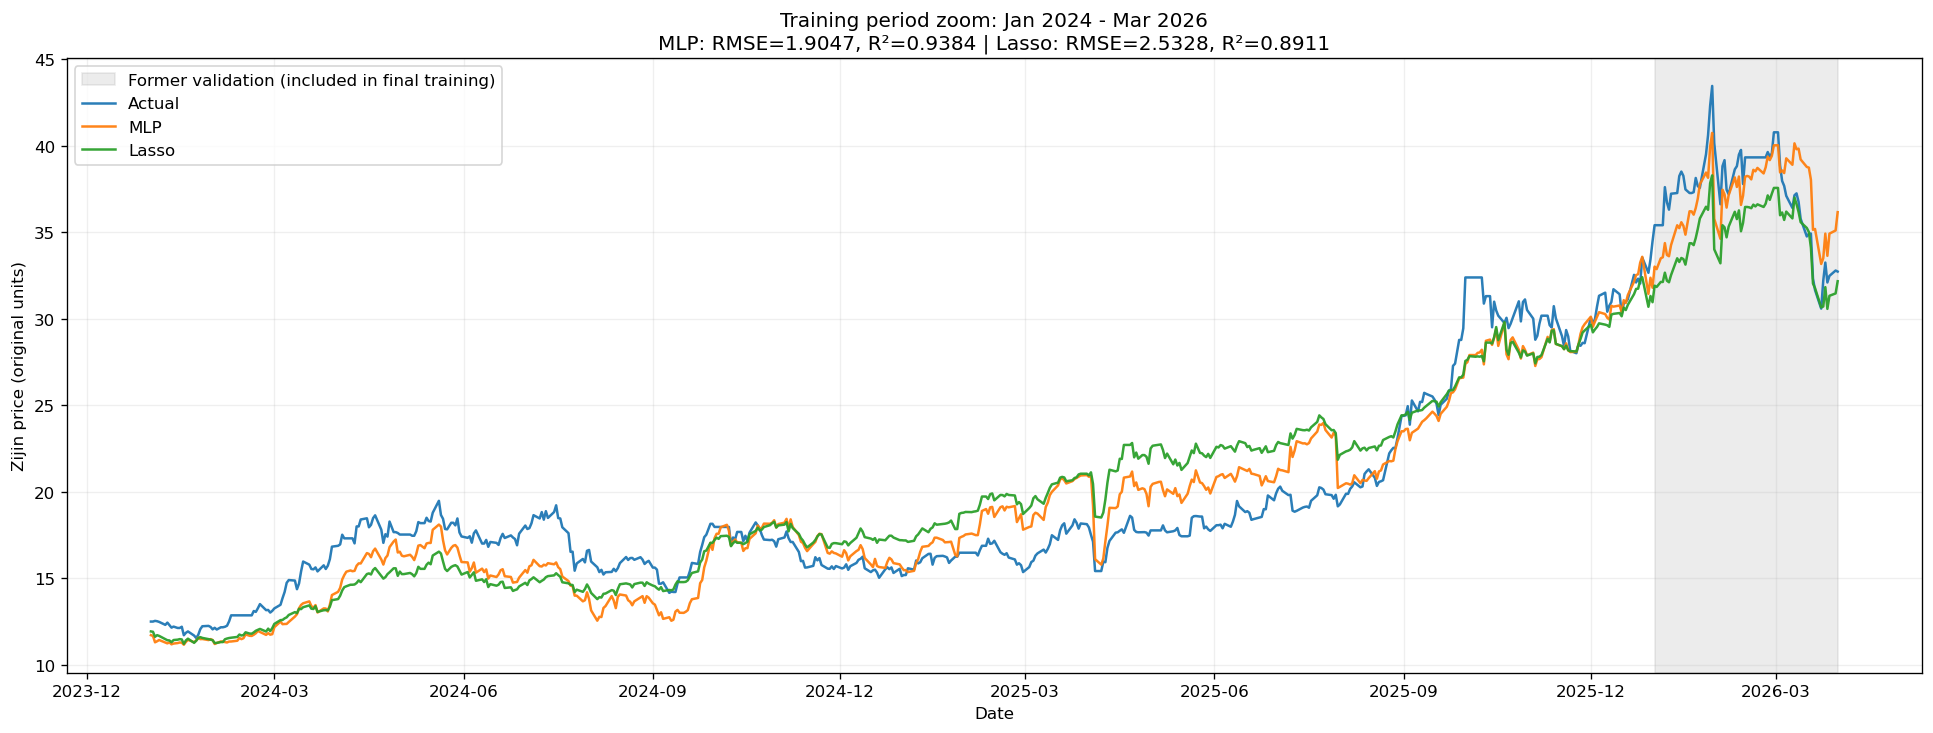

In [ ]:
import matplotlib.dates as mdates

zoom_fig, zoom_ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
zoom_ax.axvspan(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-03-31'),
               color='gray', alpha=0.15, label='Former validation (included in final training)')
for name, color in [('Actual', 'tab:blue'), ('MLP', 'tab:orange'), ('Lasso', 'tab:green')]:
    zoom_ax.plot(zoom_train.index, zoom_train[name], color=color, linewidth=1.5,
                 label=name, alpha=0.95)
zoom_ax.set_title('Training period zoom: Jan 2024 - Mar 2026\n'
    f'MLP: RMSE={zoom_metrics.loc["MLP", "RMSE"]:.4f}, R²={zoom_metrics.loc["MLP", "R²"]:.4f}'
    f' | Lasso: RMSE={zoom_metrics.loc["Lasso", "RMSE"]:.4f}, R²={zoom_metrics.loc["Lasso", "R²"]:.4f}')
zoom_ax.set(xlabel='Date', ylabel='Zijin price (original units)')
zoom_ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
zoom_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
zoom_ax.grid(alpha=0.2)
zoom_ax.legend(loc='upper left')
zoom_fig.savefig(zoom_out / 'train_2024_to_2026q1_zoom.png', dpi=140)
plt.show()


相比之前的模型,我们可以确认,针对2025-09 到 2026-01 这段时间的股价实际变化,是由于金价,铜价,债券等出现了从未出现的新情况.如果扩大训练集,将极端情况包含在内,那么后续的模型的预测会有很大的改善.  
否则,在已知的参数范围内得到的误差较小的公式,可能会由于某个参数急剧变大,对计算式产生很大的影响.让误差急剧放大.  
因此,我们应该先看一下参数的范围,保证训练集应该见过更多的情况.

此外,由于线性模型设计中没有高次项,对于一些非线性关系可能没有学到.2025年09年的部分和2026年1约的部分表现更差.  
我们认为,股票的涨跌非理性的地方也很重要.非线性模型的敏感性先天有不足.因此我们应该进一步选择神经网络.